# 04 — Close Encounters and Collision Bounce

Four scenarios that each stress the integrator in a different way:

- **A.** Tighter ellipse (`e ≈ 0.91`, periapsis `≈ 0.094`), unregularized — expect visible energy drift.
- **B.** Same ICs as A, with `:lifted_pair` — the regularizer rescues the orbit.
- **C.** **Collision bounce** on a head-on like-charge sub-critical approach (ℓ = 0, $C^0$ continuation). Uses `collision_bounce_radius` with `enabled = false` per the package convention documented in [`theory/Regularization.md`](../../../theory/Regularization.md) §7 and the memory entry behind [`docs/exploratory/CollisionBounceRegularization.md`](../../../docs/exploratory/CollisionBounceRegularization.md).
- **D.** **Intentional failure demo** — close unregularized approach with a too-coarse `dt`, caught as `retcode = :Failure`.

In [1]:
include(joinpath(@__DIR__, "common.jl"))


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


## A. Tight ellipse, unregularized

Reduce the transverse momenta to shrink angular momentum and drive a tighter periapsis. With `p_y = ±0.15` the ellipse has $L = 0.3$, $e \approx 0.91$, $r_{\text{peri}} \approx 0.094$.

[A/unreg] retcode                  = Success
[A/unreg] requested_backend        = disabled
[A/unreg] used_backend             = disabled
[A/unreg] active_steps             = 0
[A/unreg] pair_steps               = 0
[A/unreg] adaptive_pair_steps      = 0
[A/unreg] lifted_pair_steps        = 0
[A/unreg] chain_steps              = 0
[A/unreg] unregularized_steps      = 27141
[A/unreg] backend_fallback_steps   = 0
[A/unreg] total_substeps           = 27141
[A/unreg] max_substeps_used        = 1
[A/unreg] activation_count         = 0
[A/unreg] deactivation_count       = 0
[A/unreg] min_encounter_distance   = Inf
[A/unreg] max_constraint_violation = 0.000e+00
A max energy drift: 4.357e-01 %


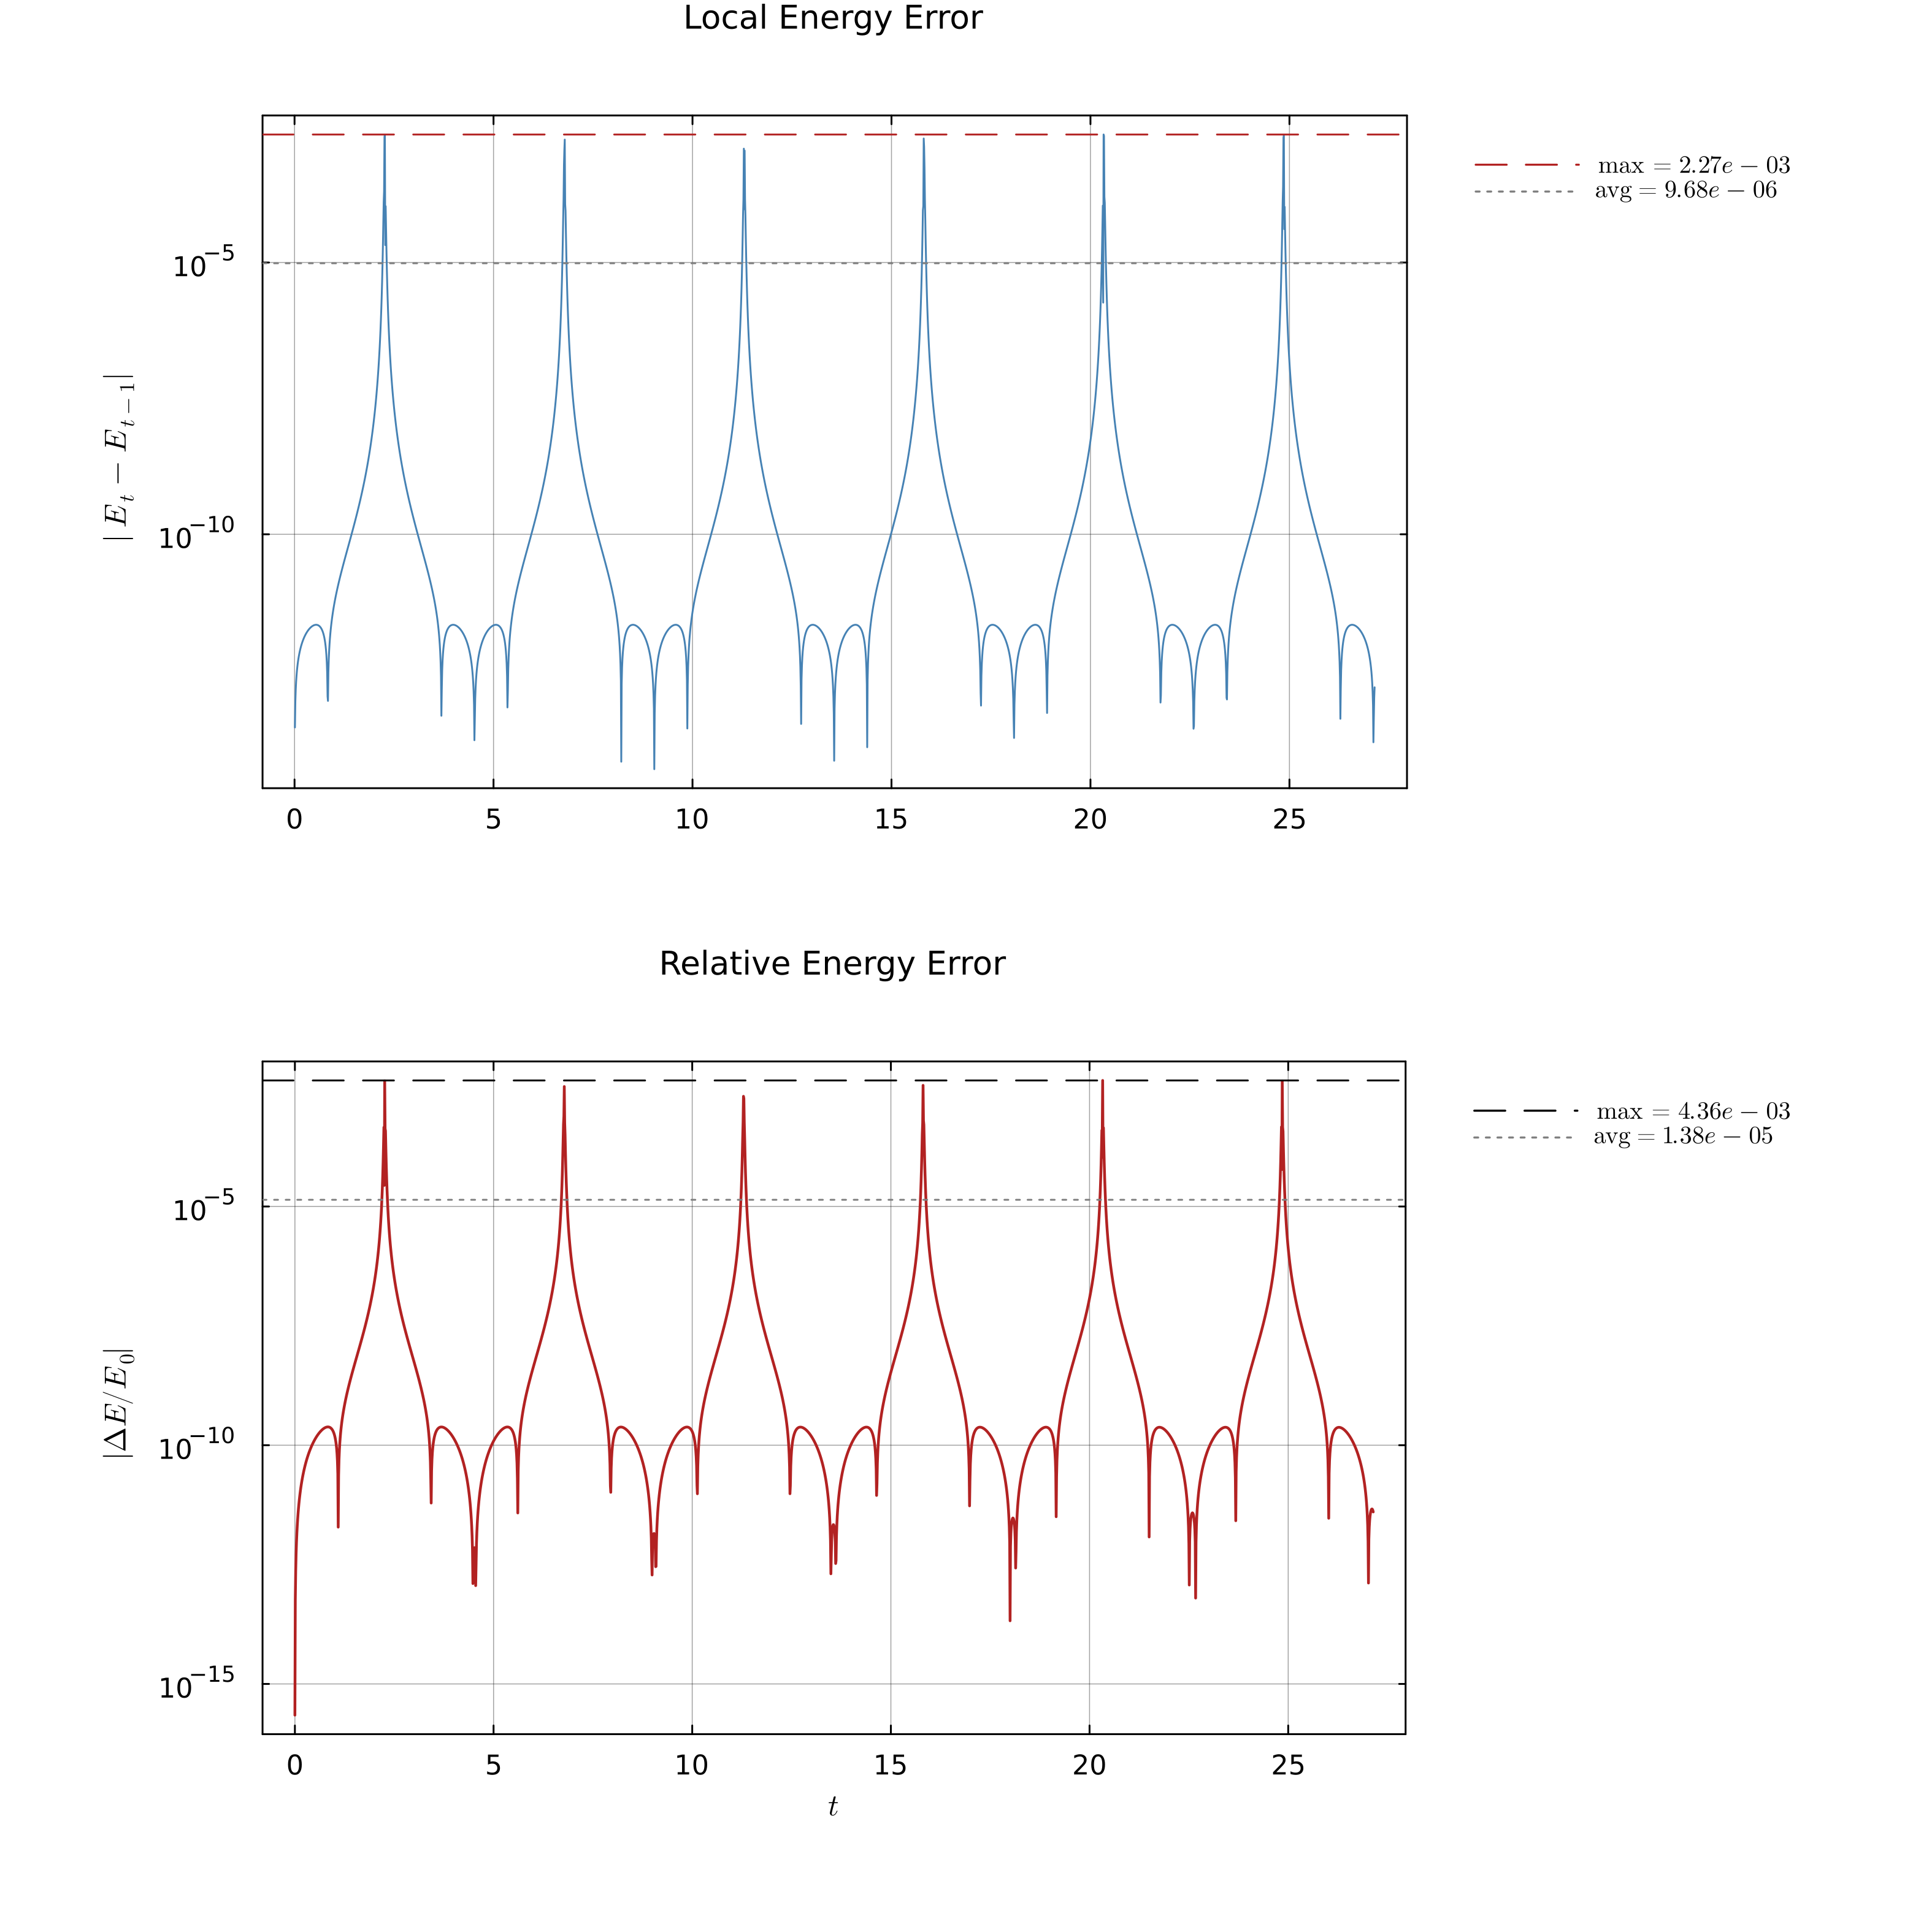

In [2]:
q0_tight = [-1.0, 0.0, 1.0, 0.0]
p0_tight = [ 0.0, -0.15, 0.0, 0.15]

system = HamiltonianSystem(2, 2)
T_orbit_tight = 2π * sqrt((1/(0.98))^3 * 0.5)   # rough, E ≈ -0.49 ⇒ a ≈ 1/0.98
tspan = (0.0, 5 * T_ORBIT_CANON)  # 5 canonical orbits, keep runtime bounded

prob_A = HamiltonianProblem(system, tspan, q0_tight, p0_tight;
    masses = [1.0, 1.0], charges = [1.0, -1.0], c = C_CANON, dt = 0.001,
)
sol_A = solve(prob_A)
print_reg_diagnostics(sol_A; label = "A/unreg")

en_A = compute_energy_timeseries(sol_A; stride = 10)
@printf("A max energy drift: %.3e %%\n", en_A.statistics.global_error_percent_max)
plot_energy_errors(en_A)

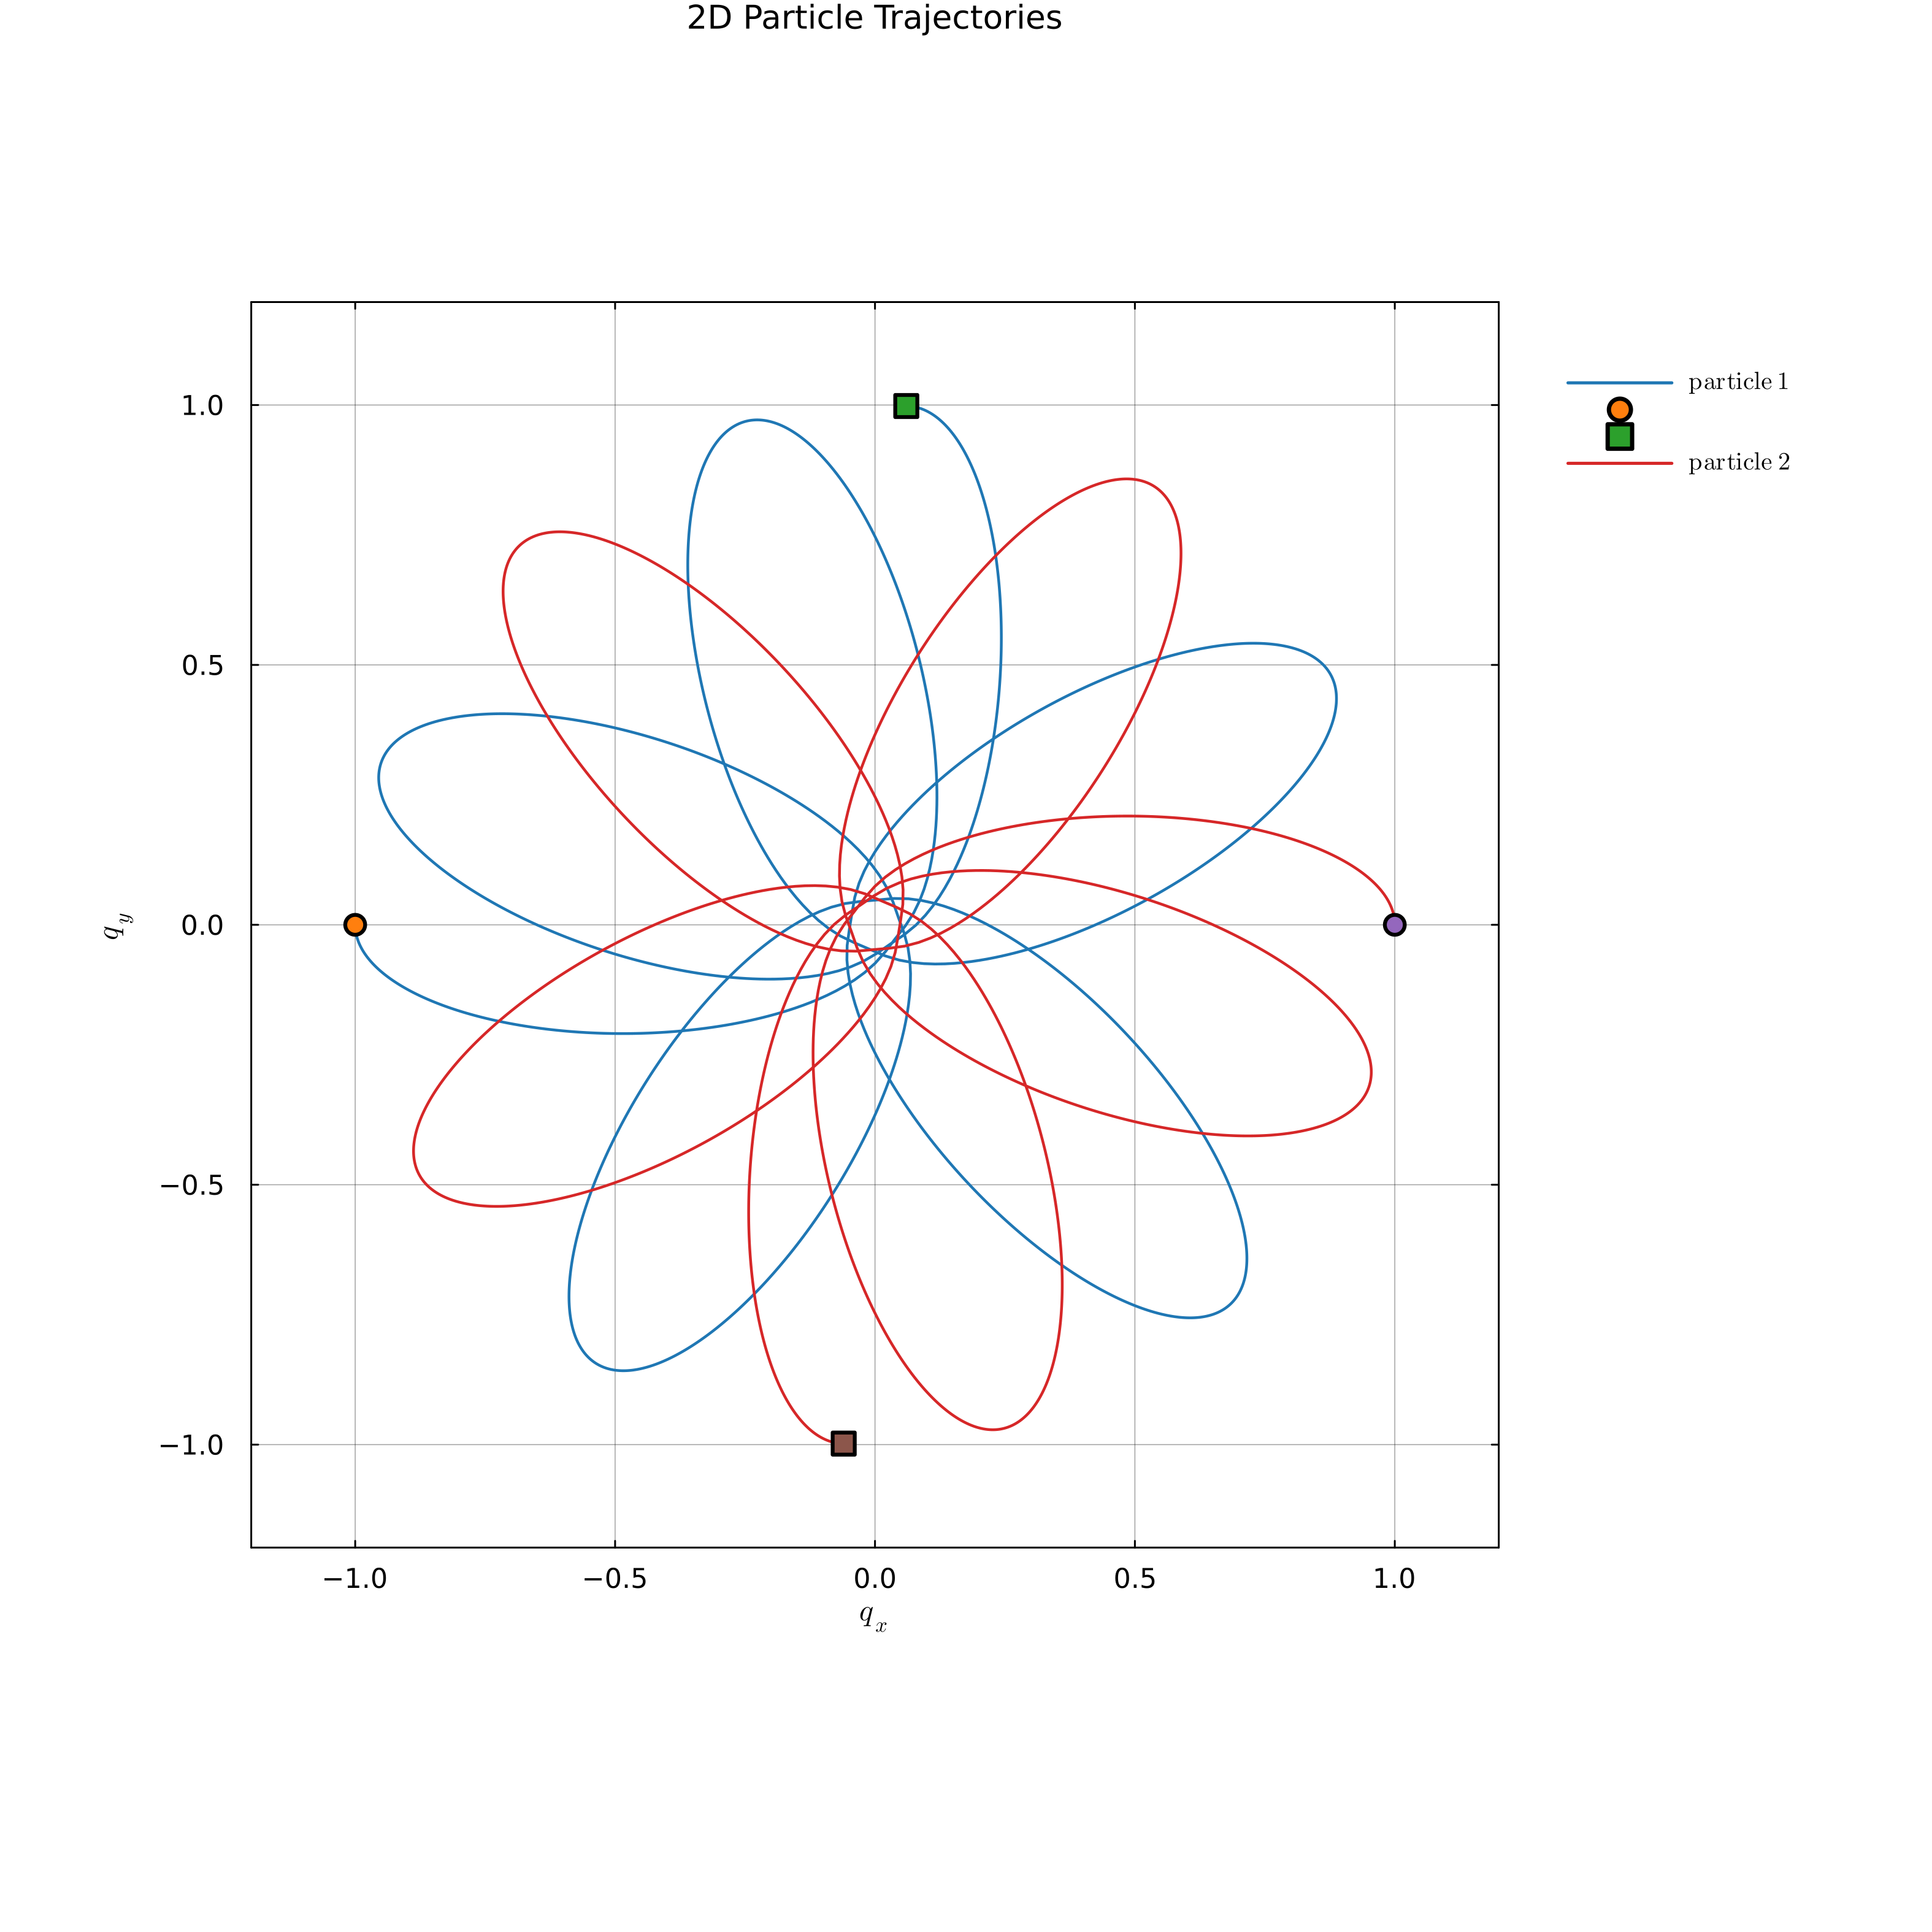

ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


In [3]:
plot_trajectories(compute_trajectory_data(sol_A, 2, 2; stride = 10))

## B. Same ICs with `:lifted_pair`

Activate the 2D Levi-Civita regularizer on the same tight ellipse.

[B/lifted] retcode                  = Success
[B/lifted] requested_backend        = lifted_pair
[B/lifted] used_backend             = lifted_pair
[B/lifted] active_steps             = 1158
[B/lifted] pair_steps               = 1158
[B/lifted] adaptive_pair_steps      = 0
[B/lifted] lifted_pair_steps        = 1158
[B/lifted] chain_steps              = 0
[B/lifted] unregularized_steps      = 25983
[B/lifted] backend_fallback_steps   = 0
[B/lifted] total_substeps           = 28989
[B/lifted] max_substeps_used        = 5
[B/lifted] activation_count         = 6
[B/lifted] deactivation_count       = 6
[B/lifted] min_encounter_distance   = 0.09424
[B/lifted] max_constraint_violation = 0.000e+00
B max energy drift: 2.314e-02 %


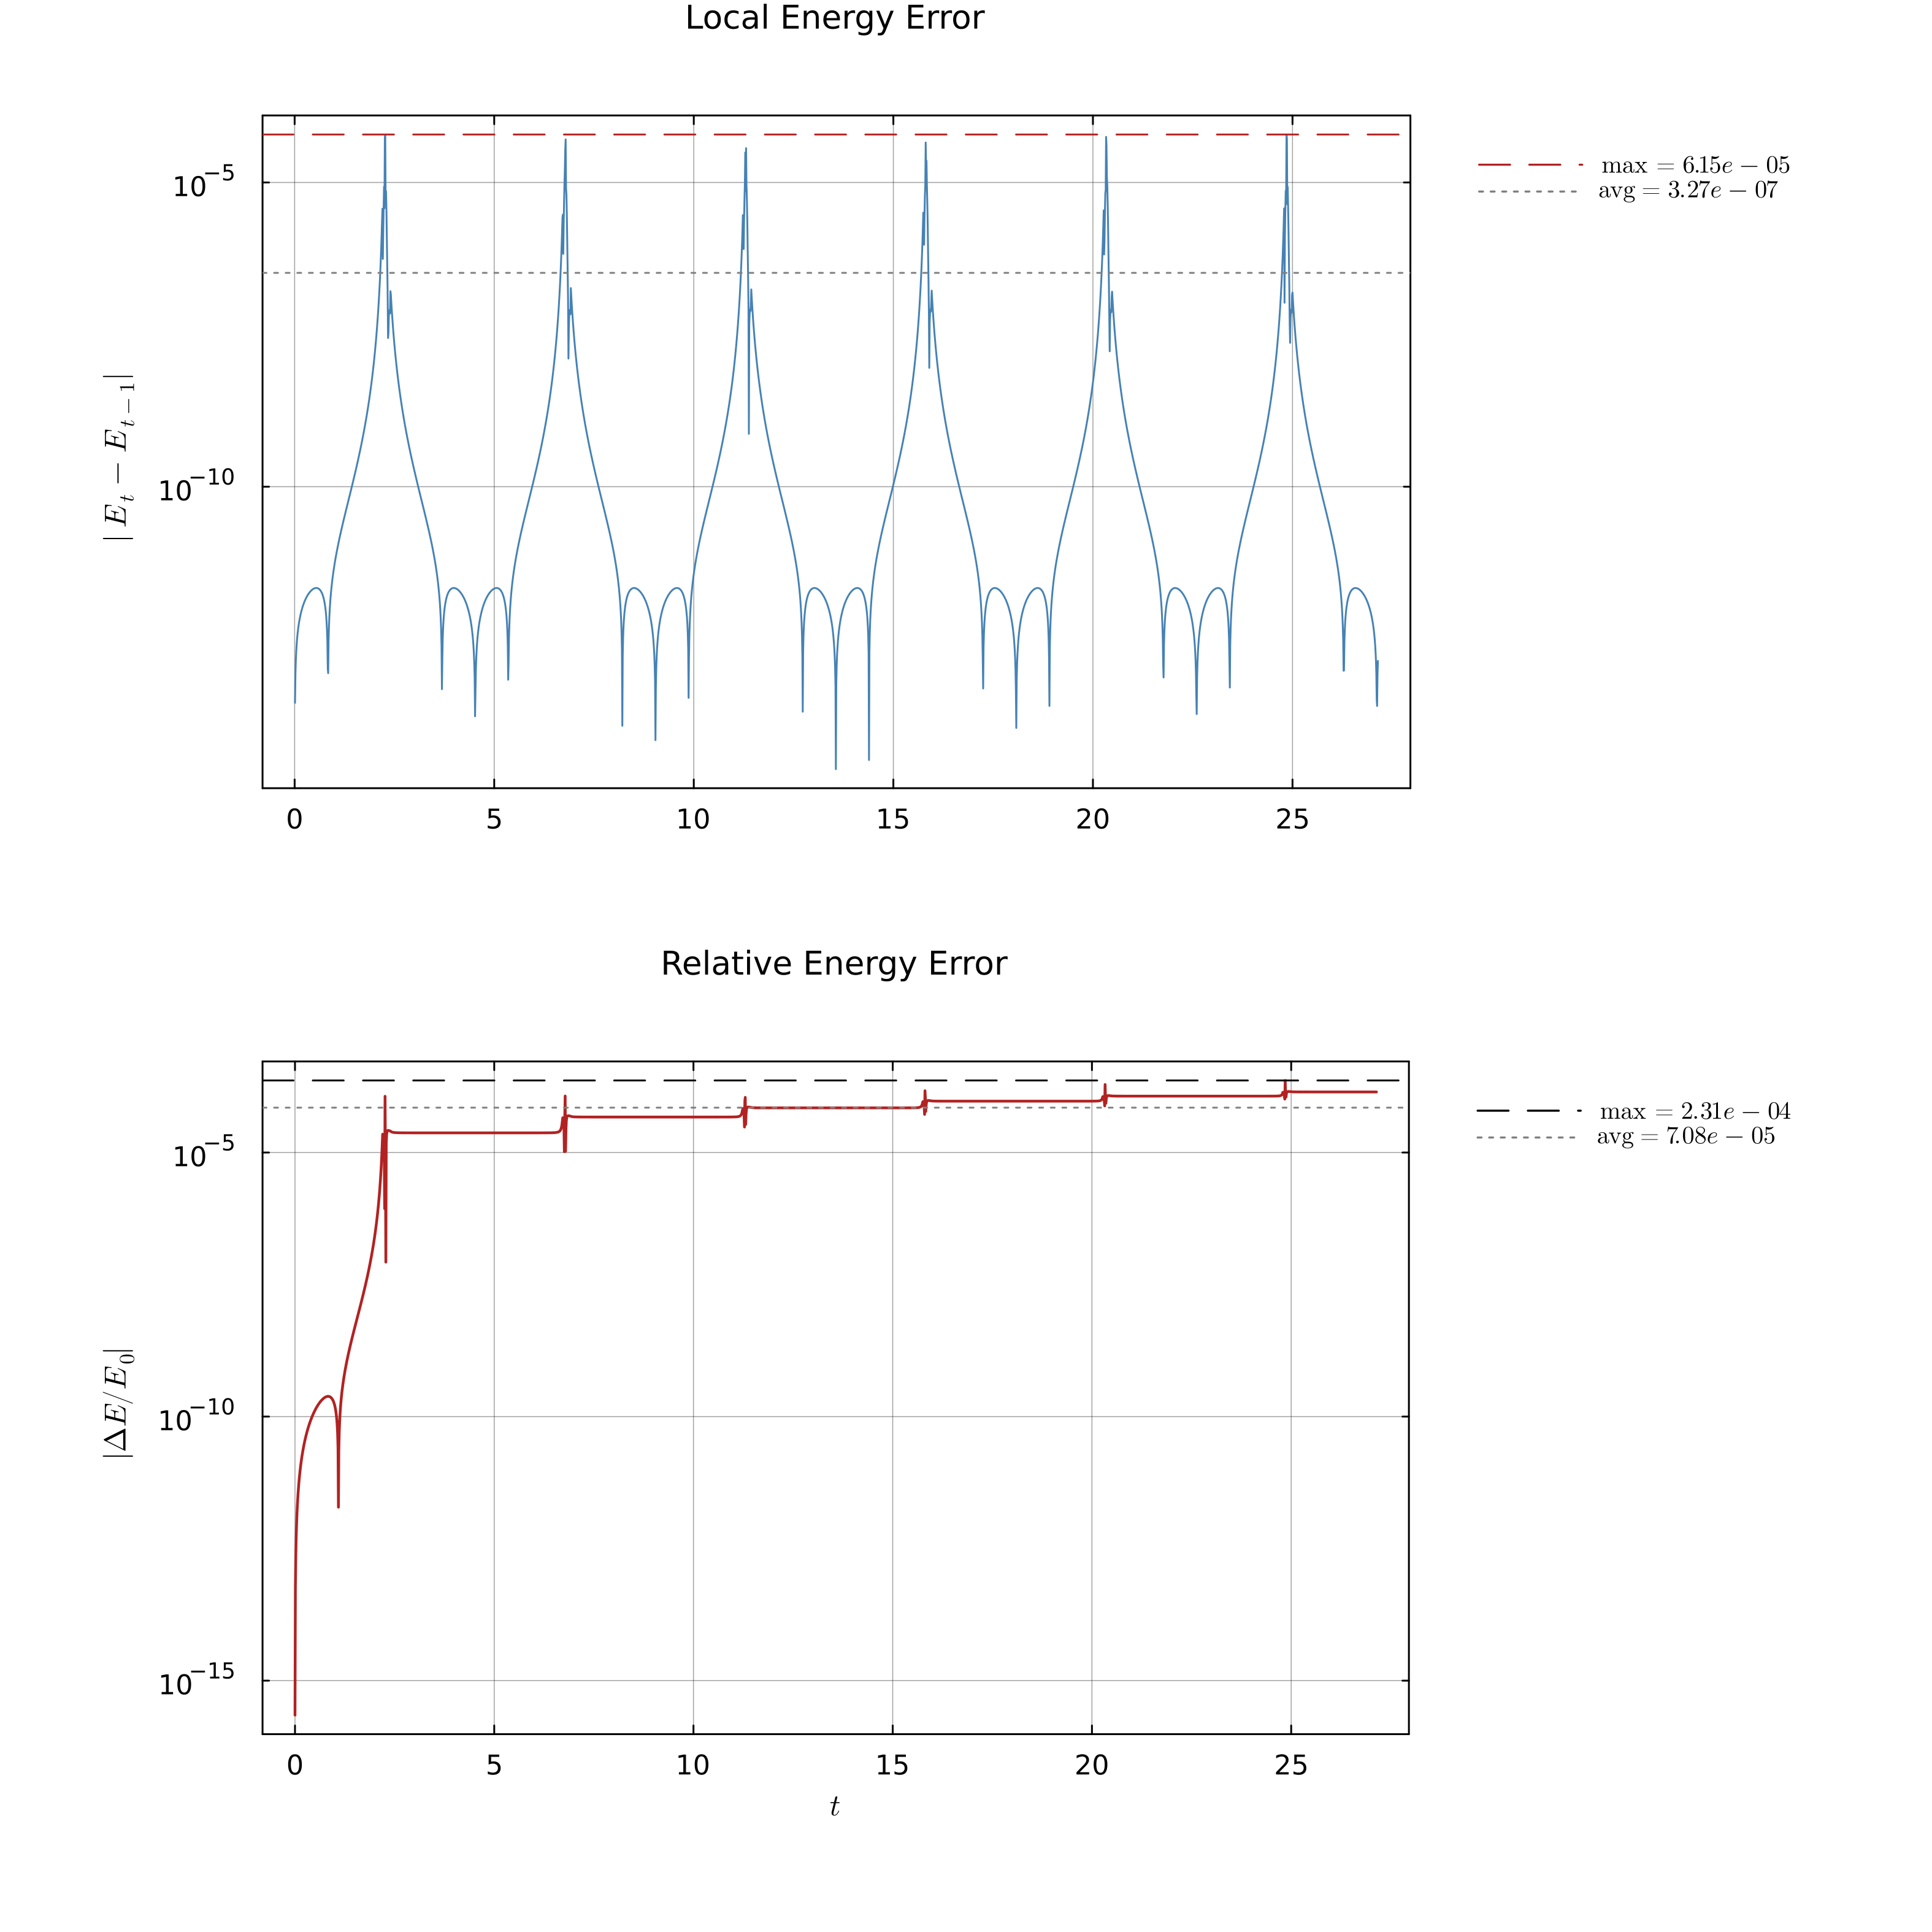

In [4]:
prob_B = HamiltonianProblem(system, tspan, q0_tight, p0_tight;
    masses = [1.0, 1.0], charges = [1.0, -1.0], c = C_CANON, dt = 0.001,
    regularization = RegularizationOptions(
        enabled = true, backend = :lifted_pair, r_on = 0.3, r_off = 0.5, max_substeps = 512,
    ),
)
sol_B = solve(prob_B)
print_reg_diagnostics(sol_B; label = "B/lifted")

en_B = compute_energy_timeseries(sol_B; stride = 10)
@printf("B max energy drift: %.3e %%\n", en_B.statistics.global_error_percent_max)
plot_energy_errors(en_B)

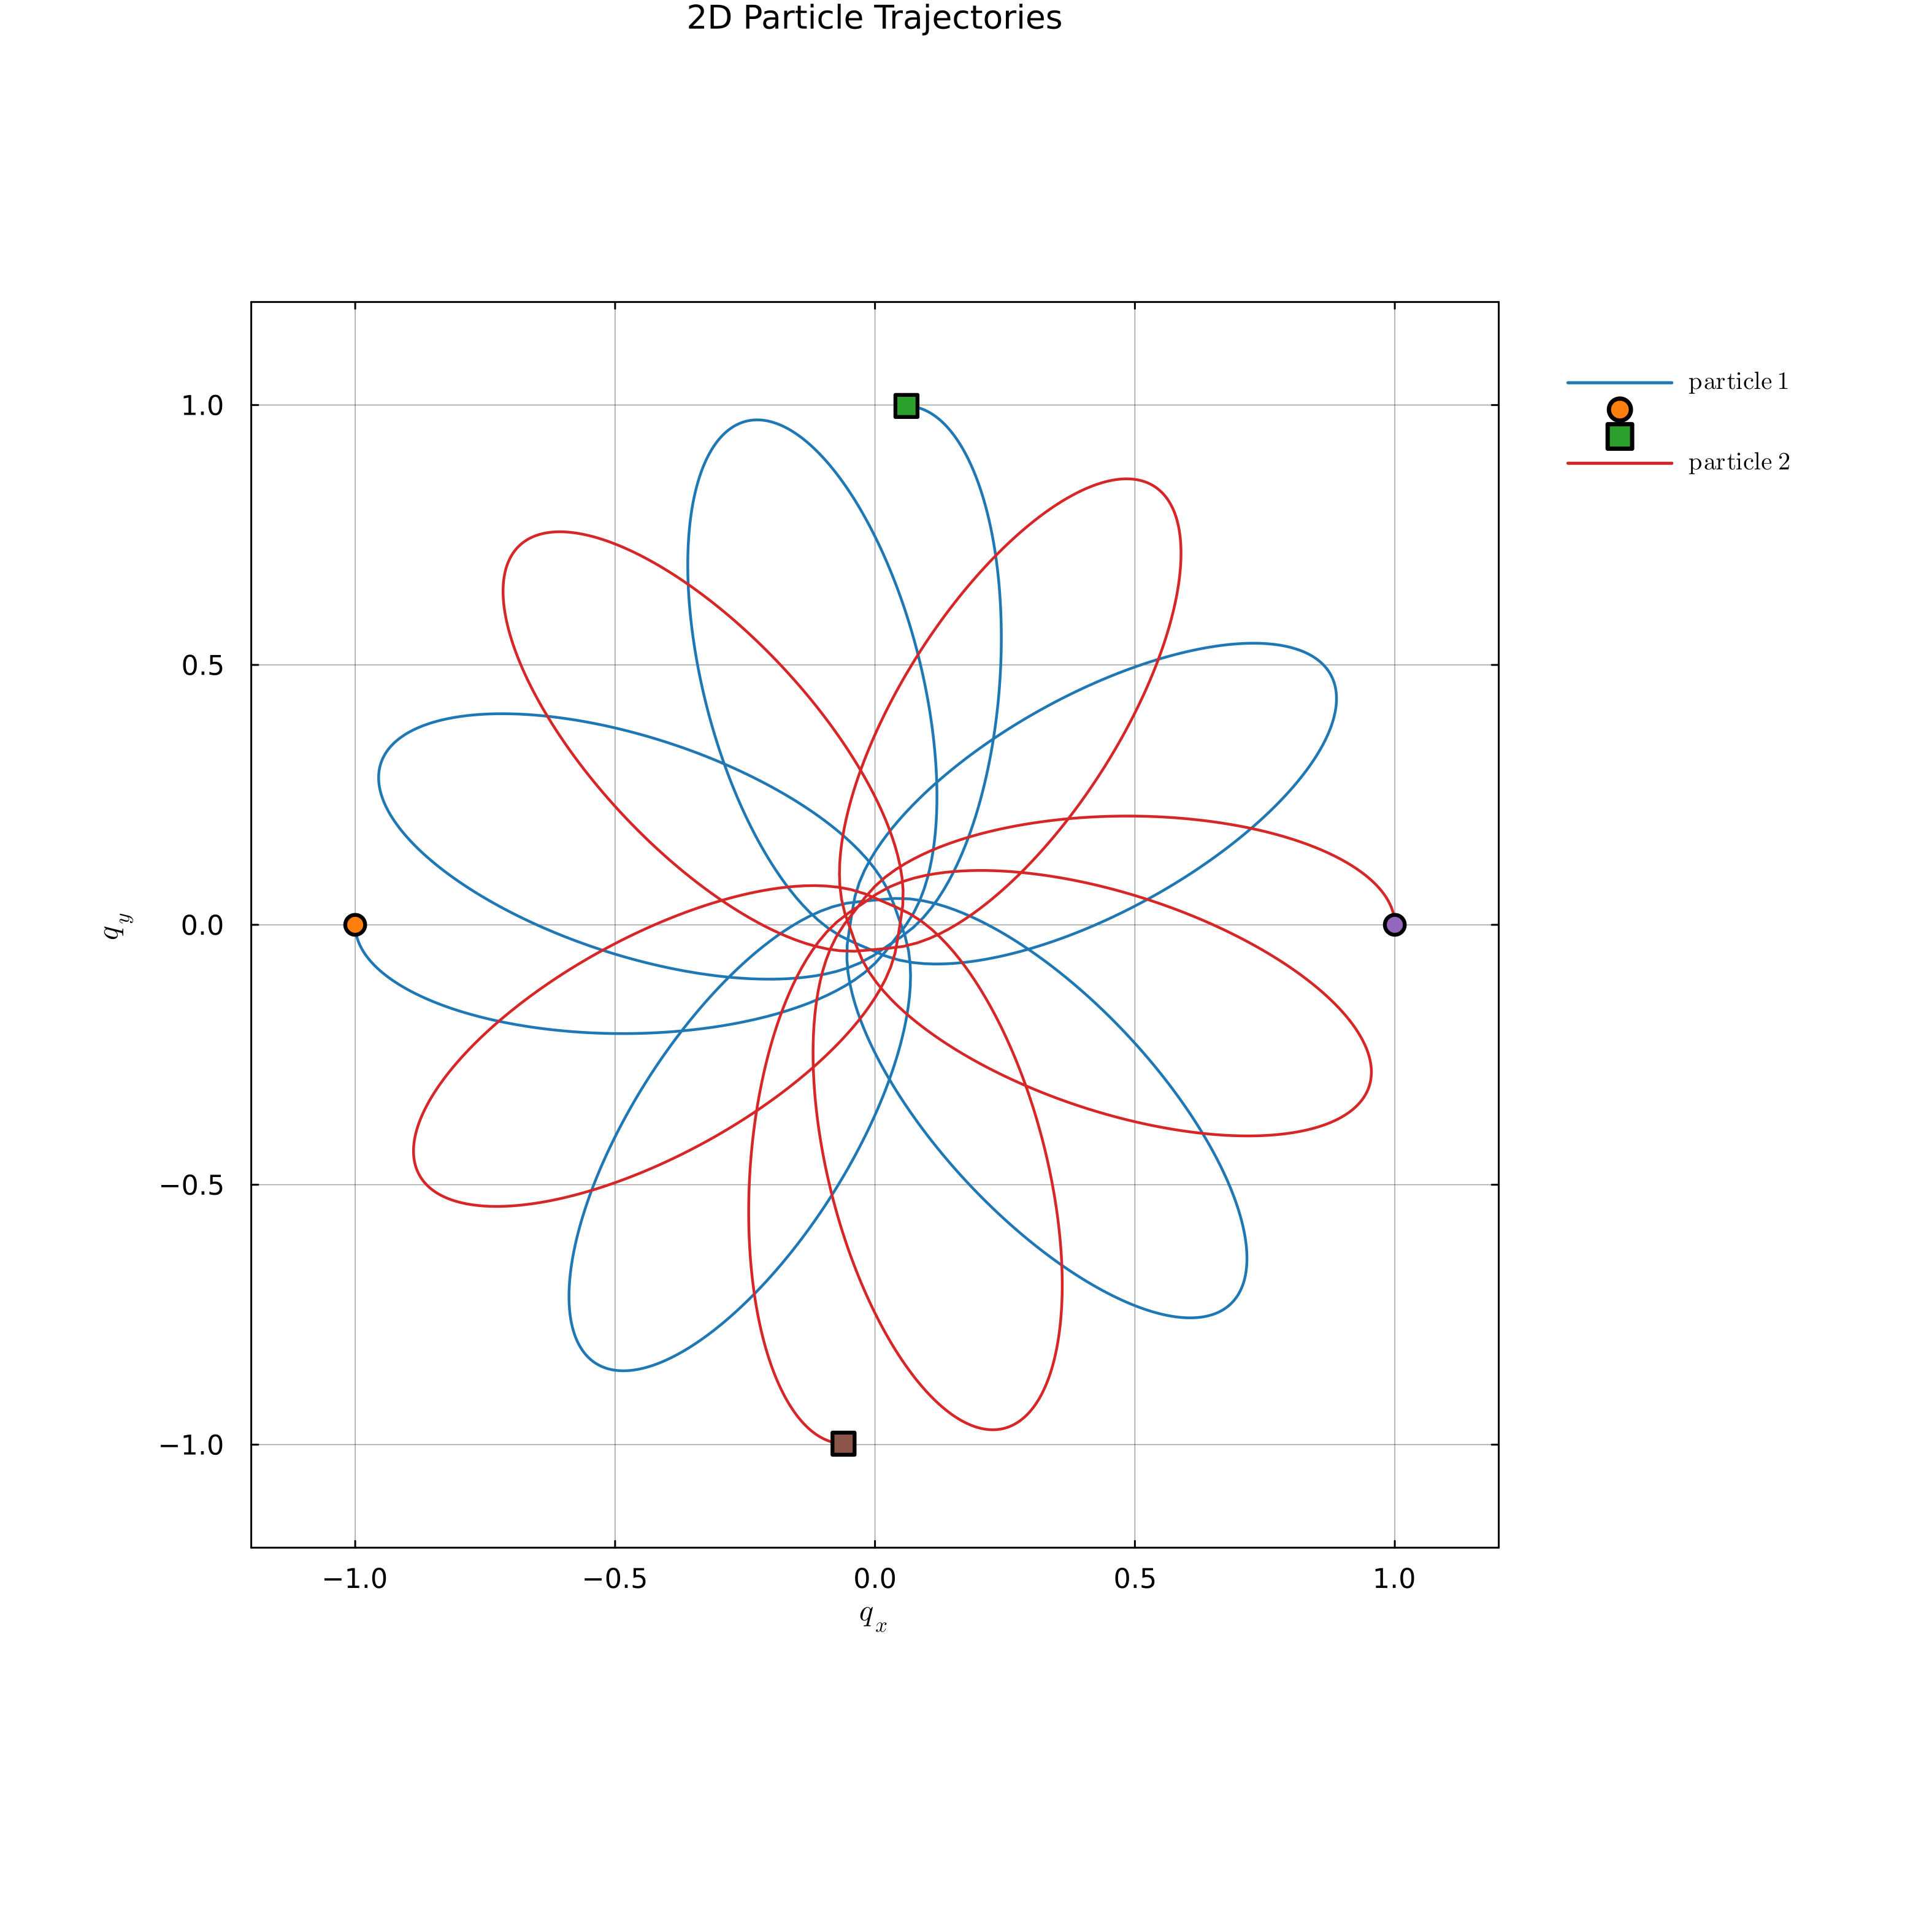

ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


In [5]:
plot_trajectories(compute_trajectory_data(sol_B, 2, 2; stride = 10))

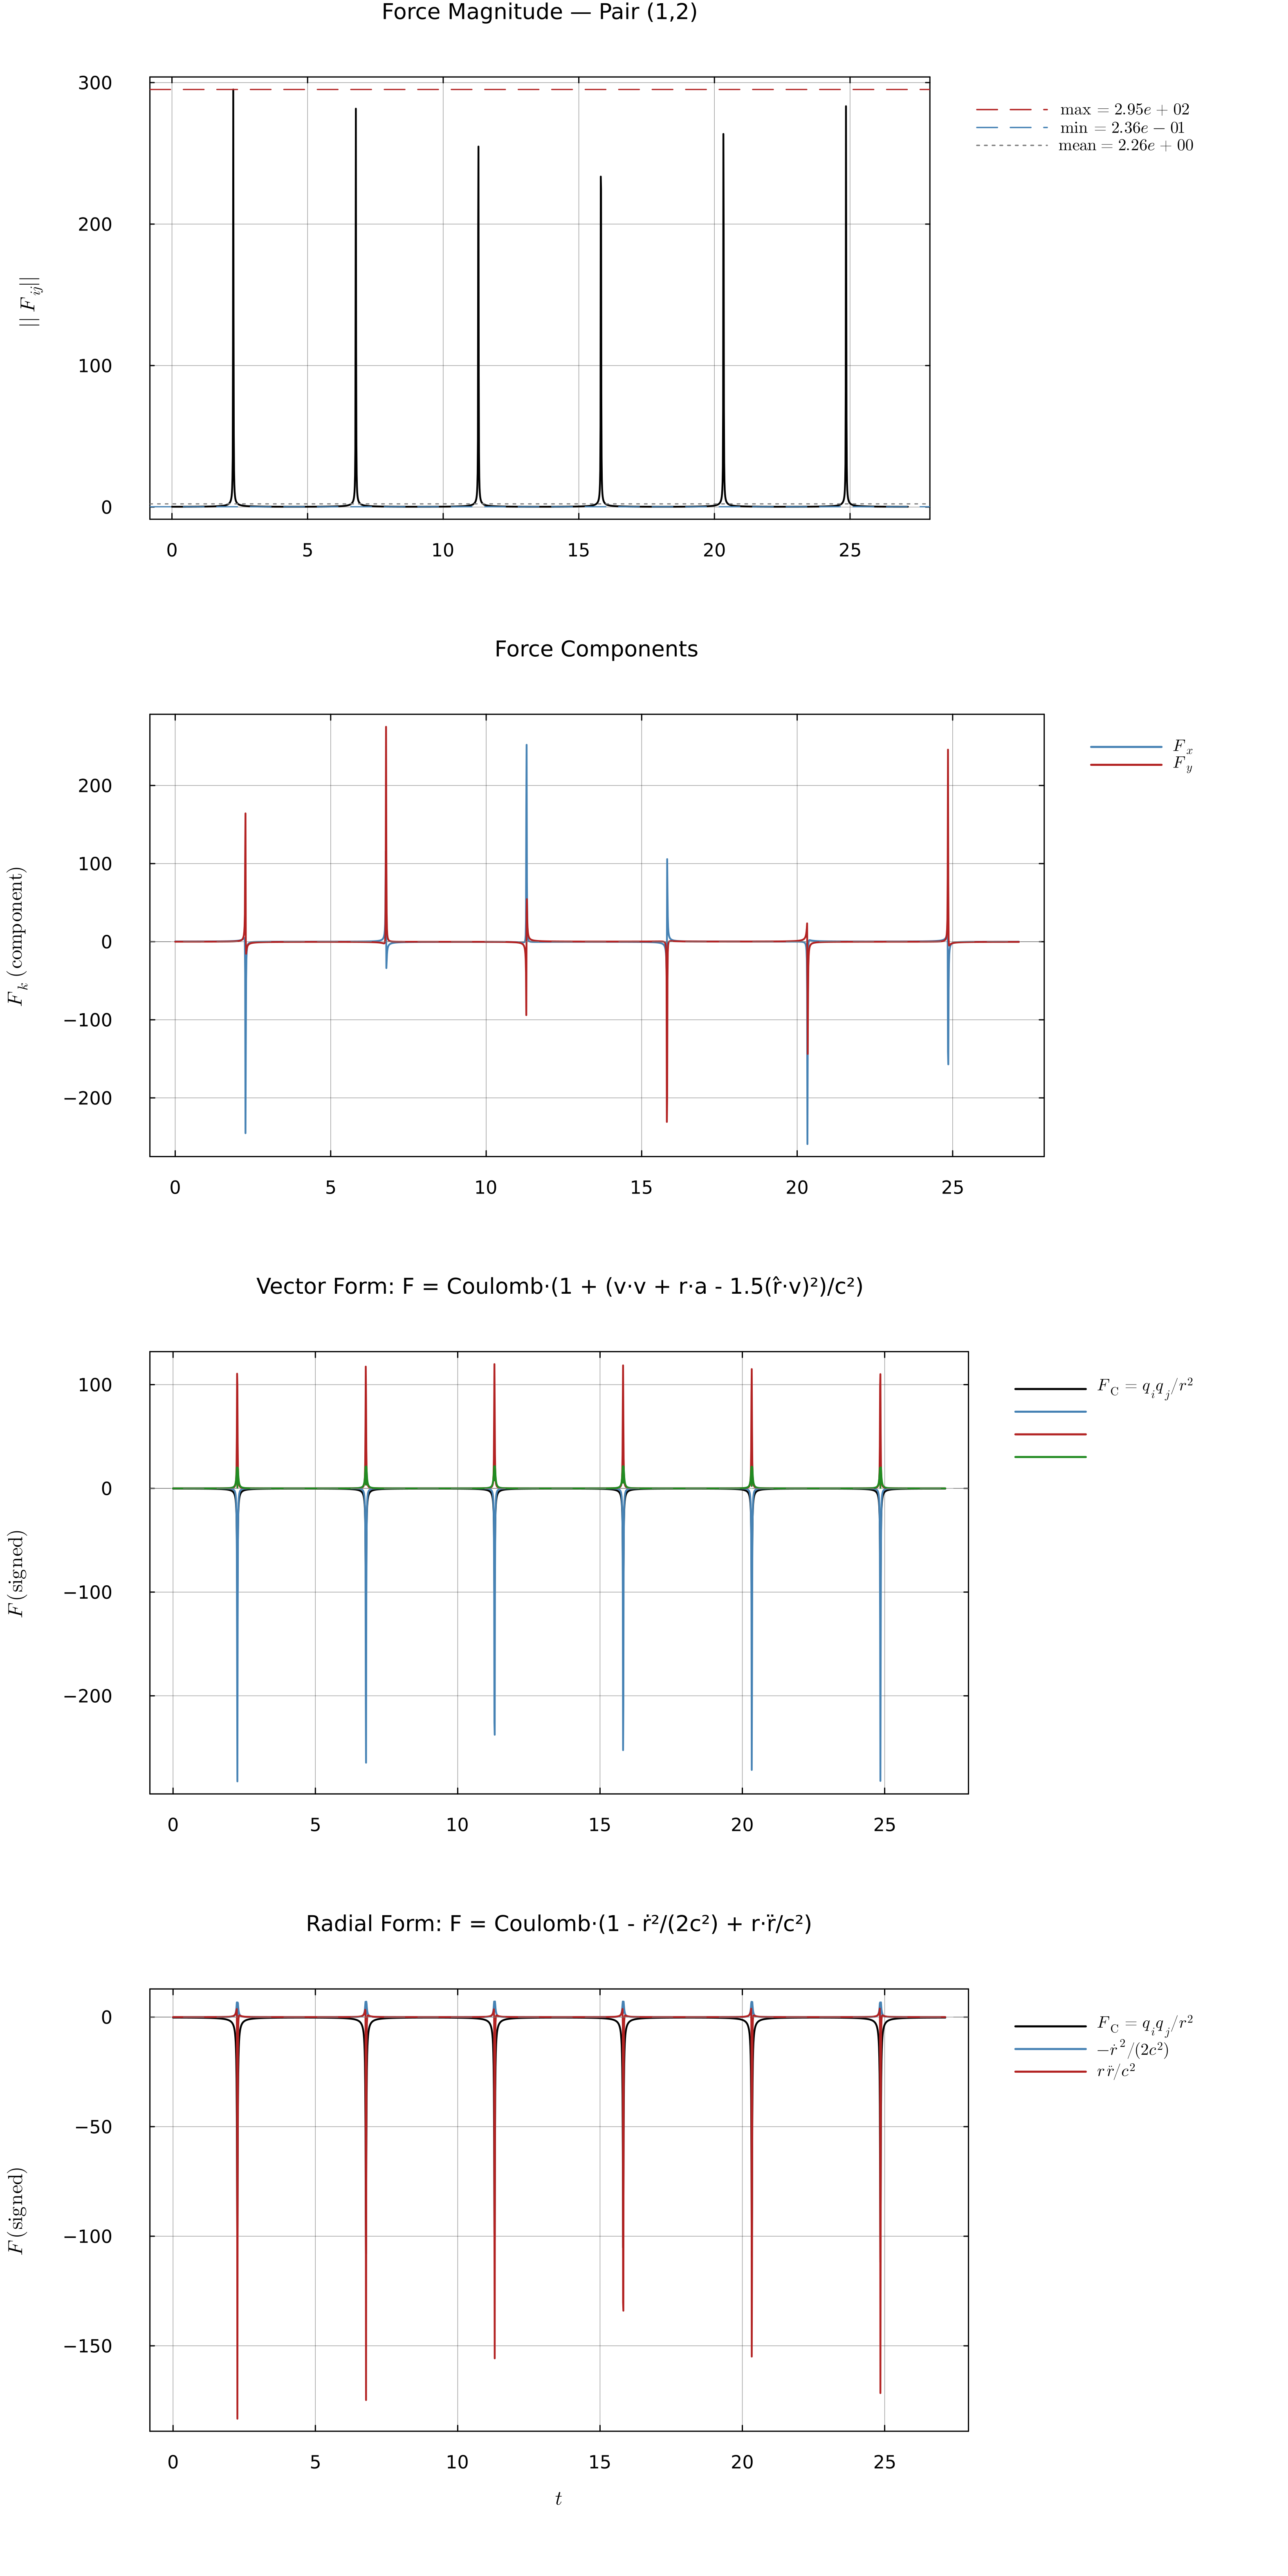

ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


In [6]:
forces_B = compute_pair_force_timeseries(sol_B, (1, 2), 2, 2, [1.0, 1.0], [1.0, -1.0], C_CANON; stride = 10)
plot_pair_forces(forces_B)

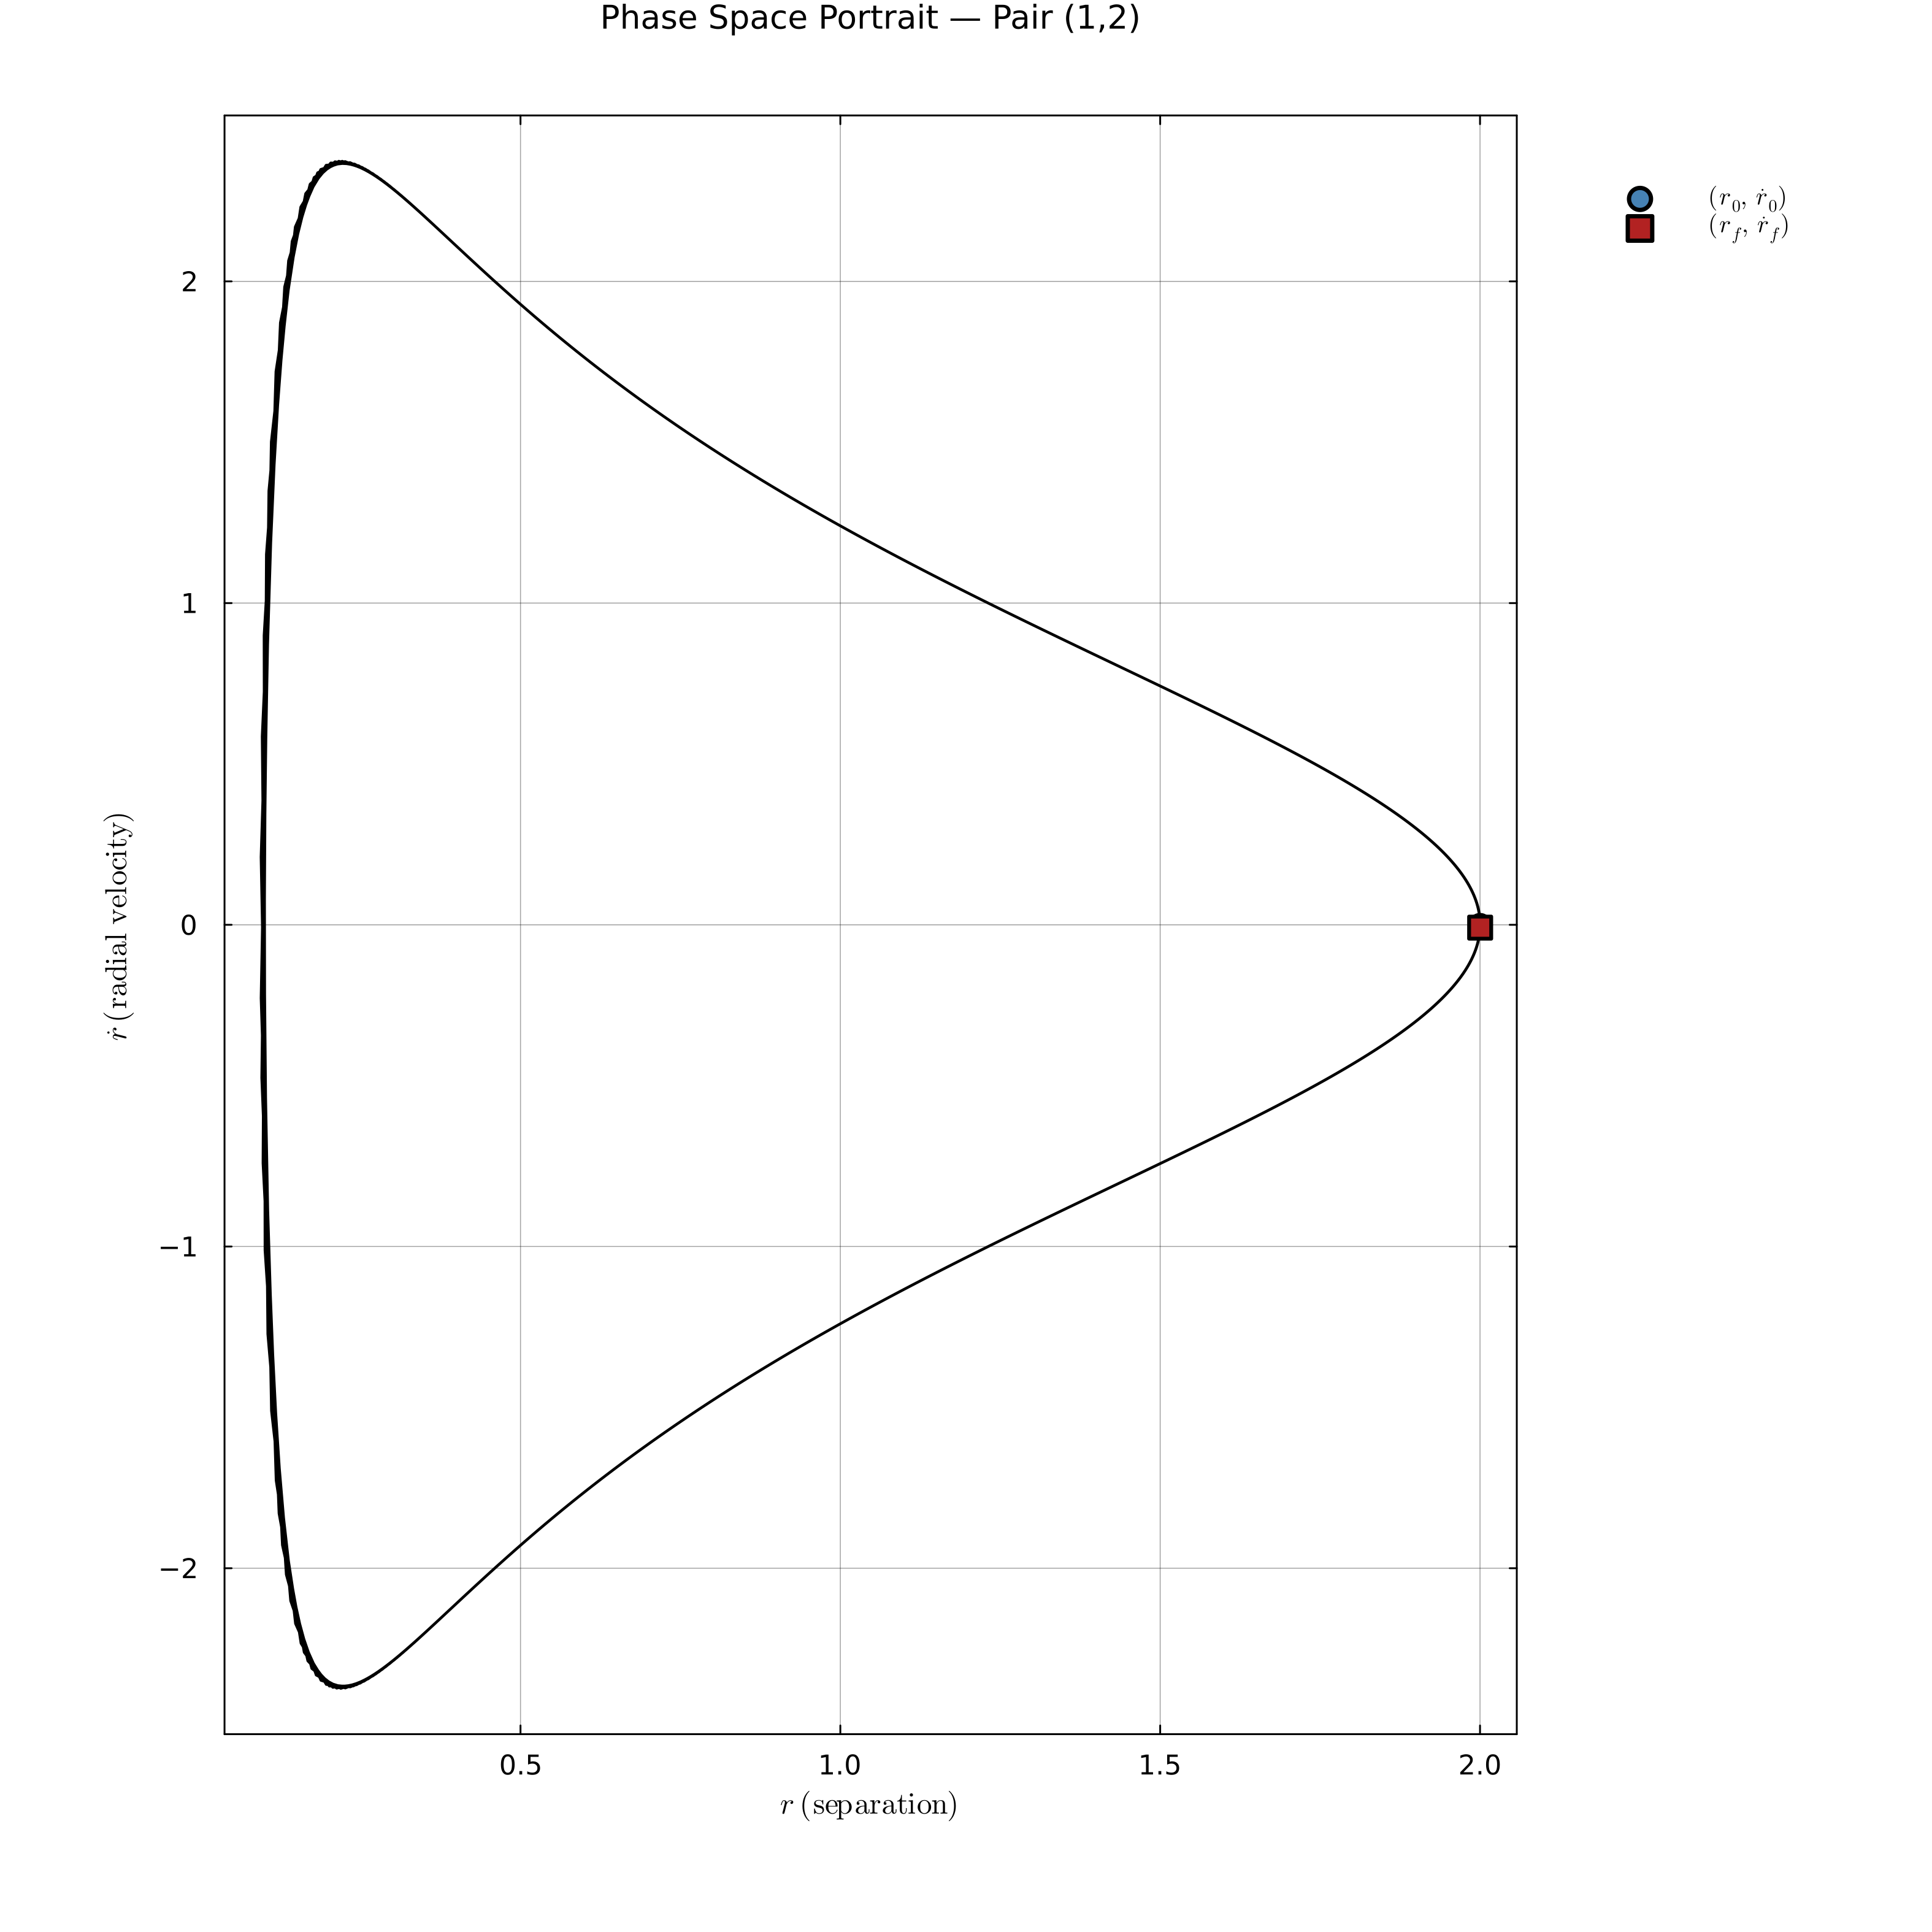

In [7]:
plot_phase_space(forces_B)

**Comparison.** Energy drift should drop by orders of magnitude between A and B. The regularized phase-space portrait shows clean periapsis passages while the unregularized orbit's energy bookkeeping degrades each pass.

## C. Collision bounce: like-charge head-on

Set up $q_1 = q_2 = +1$ particles approaching head-on with enough kinetic energy to penetrate inside the critical radius (where Weber's velocity-dependent term makes like charges attract). The collision is $C^0$-continuable via a reflection $q_{\text{rel}} \mapsto -q_{\text{rel}}$ before each step; momenta unchanged → energy preserved exactly.

Per the package convention the bounce is best used **without** the Levi-Civita regularizer — the symplectic Cartesian integrator bounds error over long runs, while the regularized chart drifts. Settings taken from `docs/exploratory/CollisionBounceRegularization.md`: `dt = 1e-4`, `bounce_r = 0.02`, `c = 4`.

In [8]:
system_like = HamiltonianSystem(2, 2)
q0_head = [-0.5, 0.0, 0.5, 0.0]
p0_head = [ 1.0, 0.0, -1.0, 0.0]   # approaching head-on

prob_C = HamiltonianProblem(system_like, (0.0, 20.0), q0_head, p0_head;
    masses  = [1.0, 1.0],
    charges = [1.0,  1.0],   # LIKE charges
    c       = C_CANON,
    dt      = 1e-4,
    regularization = RegularizationOptions(
        enabled = false,
        collision_bounce_radius = 0.02,
    ),
)
sol_C = solve(prob_C)
print_reg_diagnostics(sol_C; label = "C/bounce")

en_C = compute_energy_timeseries(sol_C; stride = 50)
@printf("C max energy drift: %.3e %%\n", en_C.statistics.global_error_percent_max)

[C/bounce] retcode                  = Success
[C/bounce] requested_backend        = disabled
[C/bounce] used_backend             = disabled
[C/bounce] active_steps             = 0
[C/bounce] pair_steps               = 0
[C/bounce] adaptive_pair_steps      = 0
[C/bounce] lifted_pair_steps        = 0
[C/bounce] chain_steps              = 0
[C/bounce] unregularized_steps      = 200000
[C/bounce] backend_fallback_steps   = 0
[C/bounce] total_substeps           = 200000
[C/bounce] max_substeps_used        = 1
[C/bounce] activation_count         = 0
[C/bounce] deactivation_count       = 0
[C/bounce] min_encounter_distance   = Inf
[C/bounce] max_constraint_violation = 0.000e+00
C max energy drift: 1.321e-07 %
[C/bounce] used_backend             = disabled
[C/bounce] active_steps             = 0
[C/bounce] pair_steps               = 0
[C/bounce] adaptive_pair_steps      = 0
[C/bounce] lifted_pair_steps        = 0
[C/bounce] chain_steps              = 0
[C/bounce] unregularized_steps      = 200

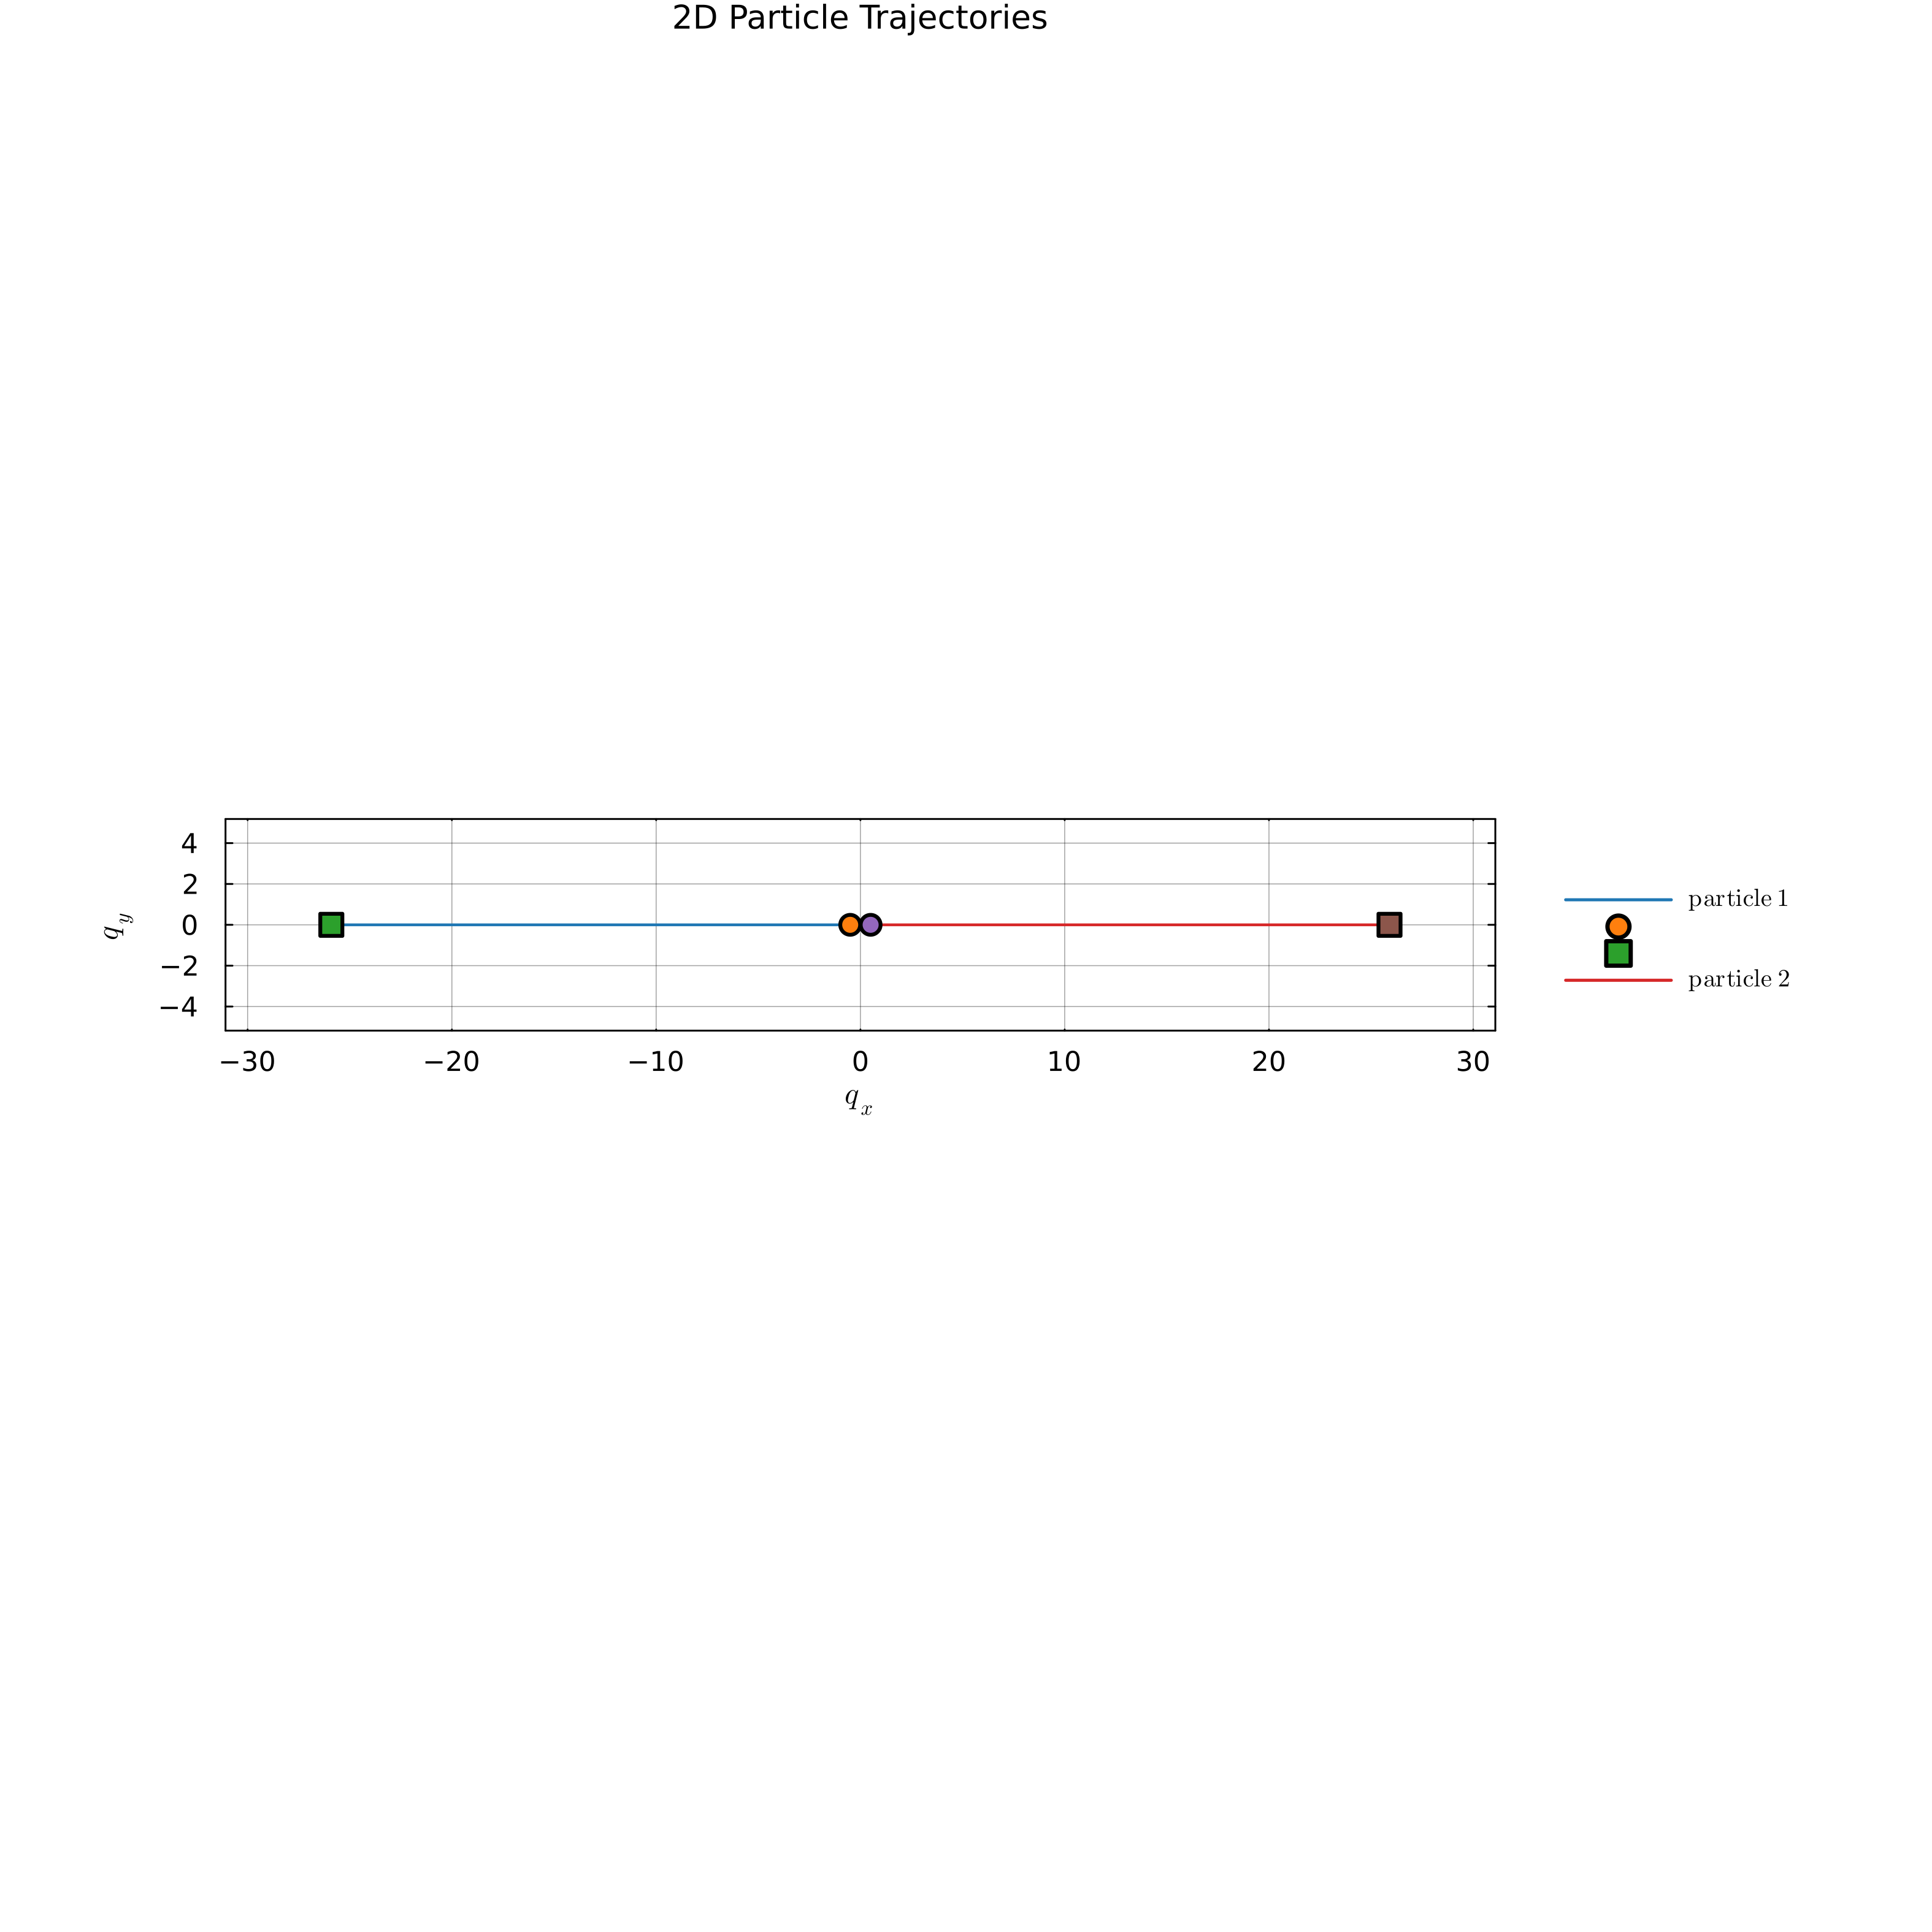

ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


In [9]:
plot_trajectories(compute_trajectory_data(sol_C, 2, 2; stride = 50))

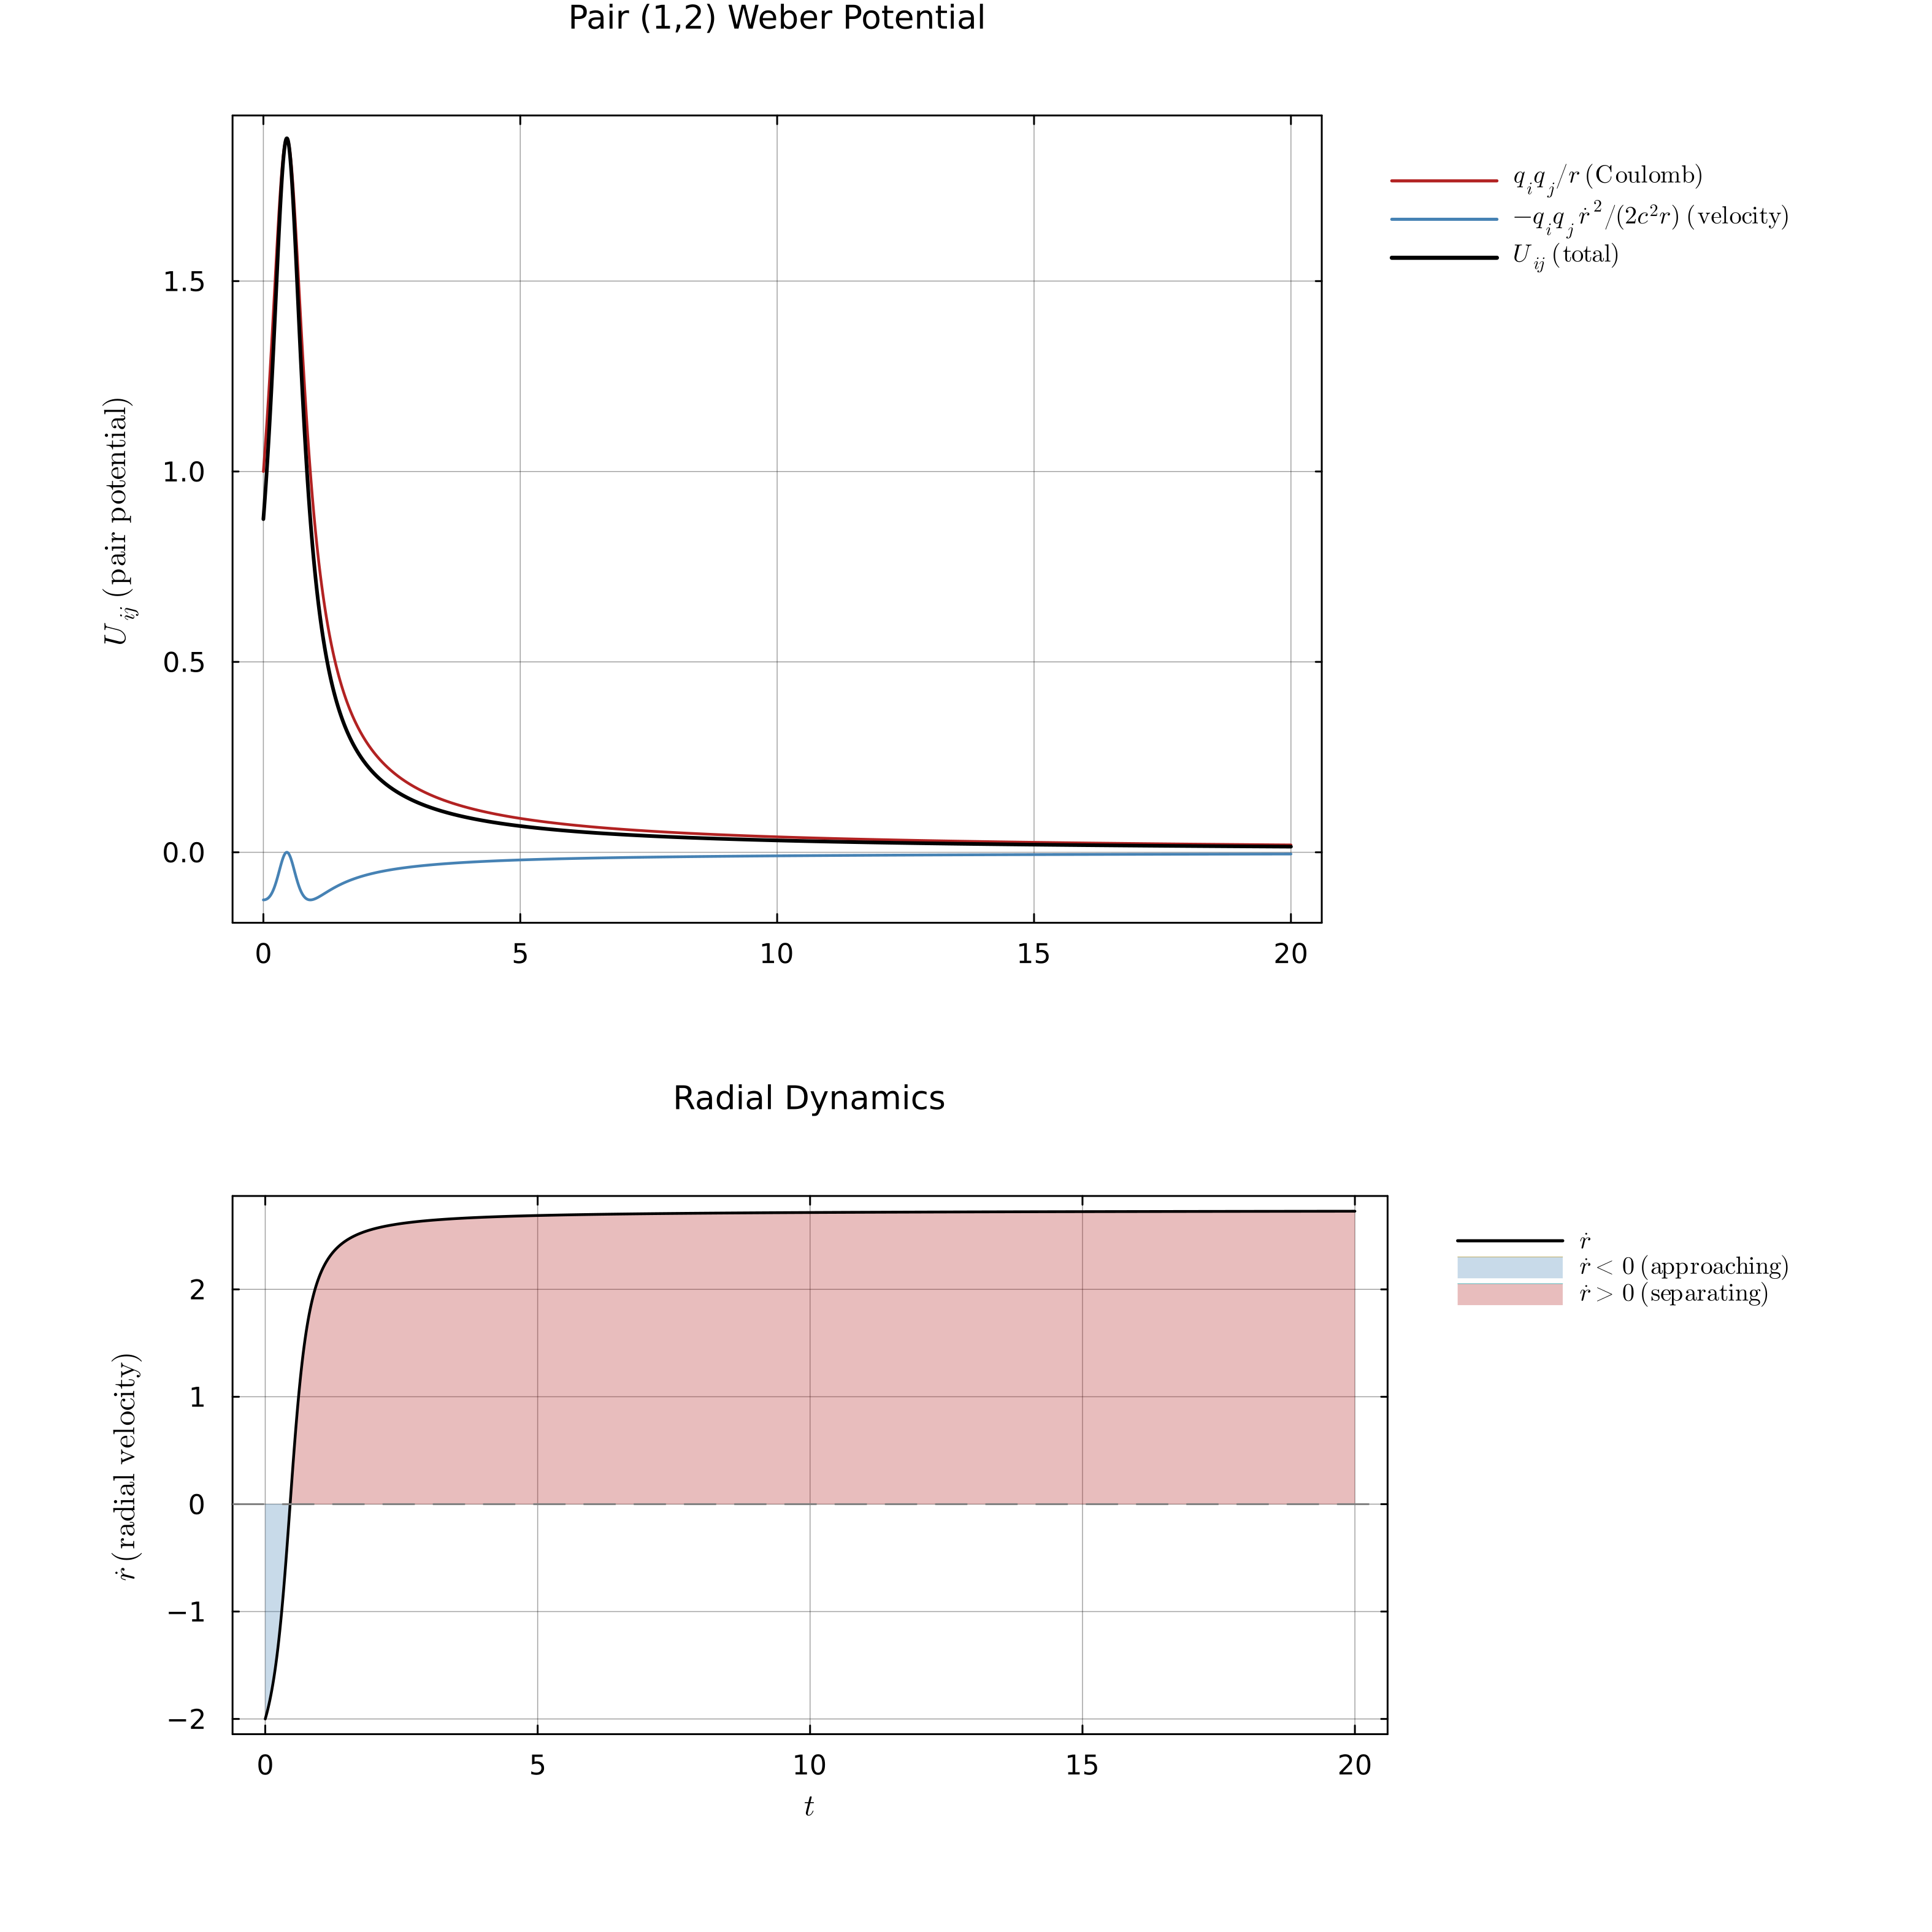

In [10]:
plot_pair_energy(en_C, (1, 2))

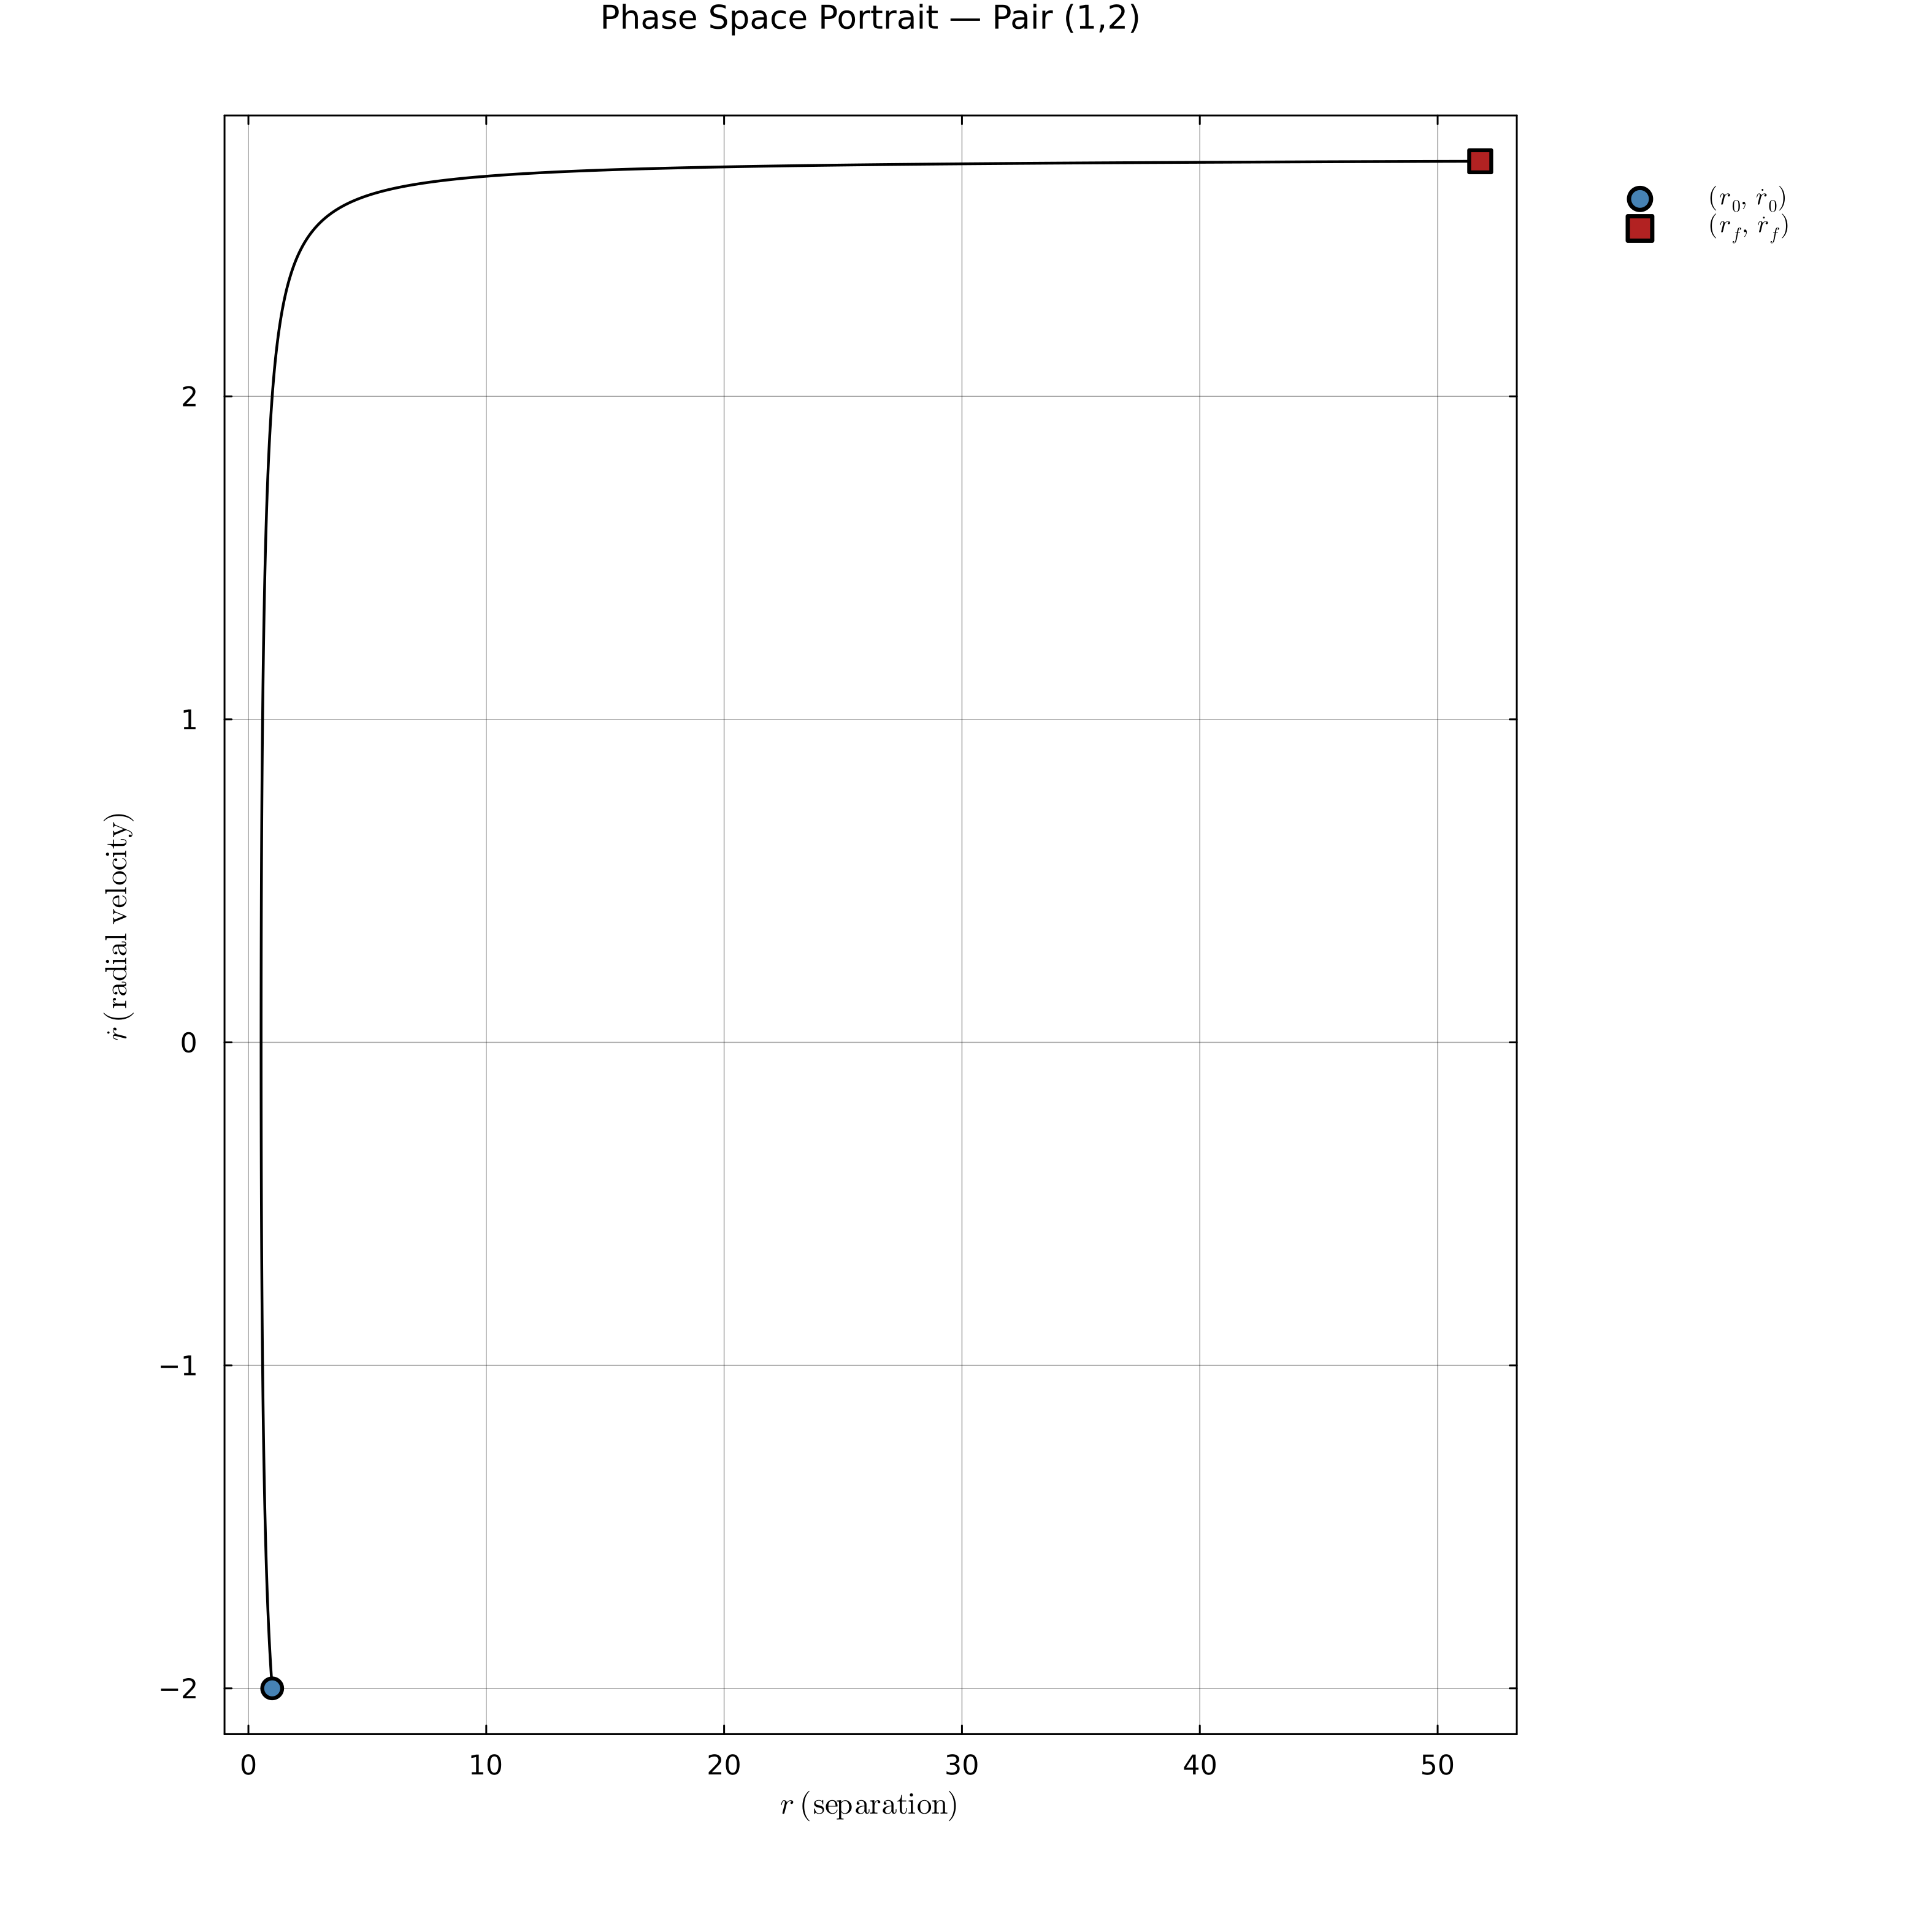

In [11]:
forces_C = compute_pair_force_timeseries(sol_C, (1, 2), 2, 2, [1.0, 1.0], [1.0, 1.0], C_CANON; stride = 50)
plot_phase_space(forces_C)

The phase-space portrait should show the characteristic bounce pattern: $r$ oscillates between the outer turning point and the bounce radius, with $\dot r$ flipping sign discretely at each reflection. Energy drift remains tiny thanks to the exact symmetry of the reflection.

## D. Intentional failure demo

Same tight ellipse as scenario A but with a deliberately coarse `dt = 0.01`. A close periapsis passage without regularization will blow up the projection fixed-point and return `retcode = :Failure`. We guard with `try/catch` to show this is recoverable at the user level.

In [12]:
# Even tighter ellipse (p_y = ±0.05 ⇒ L = 0.1, e ≈ 0.99, r_peri ≈ 0.01)
# with a coarse dt. The close periapsis with unregularized integration and a
# too-large step size is the canonical failure mode for this solver.
q0_D = [-1.0, 0.0, 1.0, 0.0]
p0_D = [ 0.0, -0.05, 0.0, 0.05]

prob_D = HamiltonianProblem(HamiltonianSystem(2, 2), (0.0, 5 * T_ORBIT_CANON), q0_D, p0_D;
    masses = [1.0, 1.0], charges = [1.0, -1.0], c = C_CANON, dt = 0.05,
)

sol_D = try
    solve(prob_D)
catch e
    @warn "solve threw" exception = e
    nothing
end

if sol_D === nothing
    println("D: solve raised an exception (fixed-point did not converge)")
else
    println("D: retcode = ", sol_D.retcode, "   steps taken = ", length(sol_D.t))
end

D: retcode = Failure   steps taken = 43


**Educational takeaway.** A coarse `dt` on an unregularized tight-encounter problem is the canonical failure mode. The remedies in order of preference are (i) enable `:lifted_pair` / `:adaptive_cartesian`, (ii) shrink `dt`, (iii) tighten `convergence_tolerance` / raise `maximum_iterations`, (iv) add a `collision_bounce_radius` if the physics supports it.